In [1]:
# install library yang dibutuhkan
!pip install -q keras-cv tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 42.8 MB/s eta 0:00:00


In [2]:
# mengaktifkan mixed precision float16 untuk menghemat VRAM ~45%
# memungkinkan batch size 8 berjalan pada GPU T4 Google Colab
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print(f"Compute dtype  : {mixed_precision.global_policy().compute_dtype}")
print(f"Variable dtype : {mixed_precision.global_policy().variable_dtype}")
print("Mixed Precision float16 aktif.")

Compute dtype  : float16
Variable dtype : float32
Mixed Precision float16 aktif.


In [3]:
# import library
import os
import sys
import glob
import random
import zipfile
import shutil
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

import tensorflow as tf
import keras_cv

print(f"TensorFlow : {tf.__version__}")
print(f"Keras CV   : {keras_cv.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

TensorFlow : 2.20.0
Keras CV   : 0.9.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# mengatur seed agar hasil reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
print(f"Random seed diatur ke: {SEED}")

Random seed diatur ke: 42


In [5]:
# mendeteksi platform Google Colab
IS_COLAB  = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    print("Platform: Google Colab")
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/Skripsi (1)'
else:
    print("Platform: Lokal")
    BASE_PATH = '.'

print(f"Base path: {BASE_PATH}")

Platform: Google Colab
Mounted at /content/drive
Base path: /content/drive/MyDrive/Skripsi (1)


In [6]:
import os
import glob
import zipfile
import shutil

print("1. Mencari dataset ZIP di Google Drive...")
zip_files = glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True)
walet_zips = [f for f in zip_files if 'walet' in f.lower()]

if not walet_zips:
    print("❌ GAGAL: Tidak menemukan file ZIP di Google Drive Anda yang memiliki kata 'walet'!")
else:
    # Jika ada lebih dari satu, ambil file yang paling BARU dimodifikasi
    walet_zips.sort(key=os.path.getmtime, reverse=True)
    zip_path = walet_zips[0]
    print(f"✅ DITEMUKAN {len(walet_zips)} file ZIP. Memilih yang TERBARU: {zip_path}")

    DATASET_DIR = "/content/dataset_walet"

    print("2. Menghapus folder dataset lama (jika ada)...")
    if os.path.exists(DATASET_DIR):
        shutil.rmtree(DATASET_DIR)

    print("3. Mengekstrak dataset baru...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATASET_DIR)

    print("4. Memeriksa struktur folder...")
    # Cek apakah folder train tersembunyi di dalam subfolder lain (kasus folder ganda)
    if not os.path.exists(os.path.join(DATASET_DIR, 'train')):
        nested_train = glob.glob(f"{DATASET_DIR}/**/train", recursive=True)
        if nested_train:
            real_root = os.path.dirname(nested_train[0])
            print(f"⚠️ Folder train tersembunyi di dalam: {real_root}. Sedang diperbaiki...")
            for item in os.listdir(real_root):
                source_item = os.path.join(real_root, item)
                dest_item = os.path.join(DATASET_DIR, item)
                if not os.path.exists(dest_item):
                    shutil.move(source_item, DATASET_DIR)
            print("✅ Struktur folder berhasil disesuaikan!")
        else:
            print("❌ GAGAL: Folder 'train' tidak ditemukan sama sekali di dalam ZIP!")
    else:
        print("✅ Folder 'train' sudah berada di posisi yang benar!")

    print("\n🎉 EKSTRAKSI SELESAI PENUH. Silakan jalankan sel 'Memuat daftar file dataset...' sekarang!")


1. Mencari dataset ZIP di Google Drive...
✅ DITEMUKAN 4 file ZIP. Memilih yang TERBARU: /content/drive/MyDrive/Skripsi/Dataset/dataset_walet.zip
2. Menghapus folder dataset lama (jika ada)...
3. Mengekstrak dataset baru...
4. Memeriksa struktur folder...
✅ Folder 'train' sudah berada di posisi yang benar!

🎉 EKSTRAKSI SELESAI PENUH. Silakan jalankan sel 'Memuat daftar file dataset...' sekarang!


In [7]:
# menampilkan struktur folder dataset
def show_dir_tree(root, max_depth=2, _depth=0):
    if _depth > max_depth:
        return
    try:
        entries = sorted(Path(root).iterdir())[:15]
    except (NotADirectoryError, FileNotFoundError):
        return
    for entry in entries:
        indent = "  " * _depth
        icon   = "📁" if entry.is_dir() else "📄"
        print(f"{indent}{icon} {entry.name}")
        if entry.is_dir():
            show_dir_tree(entry, max_depth, _depth + 1)

print(f"Struktur folder dataset ({DATASET_DIR}):")
show_dir_tree(DATASET_DIR)

Struktur folder dataset (/content/dataset_walet):
📄 README.dataset.txt
📄 README.roboflow.txt
📁 train
  📄 Salinan-1774012341205_png.rf.3a957cbce206cbf632aaf40d00a9df10.jpg
  📄 Salinan-1774012341205_png.rf.3a957cbce206cbf632aaf40d00a9df10_mask.png
  📄 Salinan-1774012341205_png.rf.b46299078e8b1df3c82b41455374403a.jpg
  📄 Salinan-1774012341205_png.rf.b46299078e8b1df3c82b41455374403a_mask.png
  📄 Salinan-IMG_20260301_152930_161_png.rf.917ee561a876ee3702c120187a6fb59d.jpg
  📄 Salinan-IMG_20260301_152930_161_png.rf.917ee561a876ee3702c120187a6fb59d_mask.png
  📄 Salinan-IMG_20260301_152930_161_png.rf.eebd058f385bc157fe25e37641d8474c.jpg
  📄 Salinan-IMG_20260301_152930_161_png.rf.eebd058f385bc157fe25e37641d8474c_mask.png
  📄 Salinan-IMG_20260301_153001_842_png.rf.04c4044a0fb6ccf1fda828da0b0e0c91.jpg
  📄 Salinan-IMG_20260301_153001_842_png.rf.04c4044a0fb6ccf1fda828da0b0e0c91_mask.png
  📄 Salinan-IMG_20260301_153001_842_png.rf.8f3f791175569eb909607bcf082ae1fe.jpg
  📄 Salinan-IMG_20260301_153001_84

In [8]:
# konfigurasi dataset
# IMAGE_SIZE diturunkan dari 512x512 ke 384x384 untuk menghemat VRAM ~44%
# dikombinasikan dengan mixed precision, total penghematan VRAM ~65%
# sehingga batch size 8 dapat berjalan pada GPU T4 Google Colab (15GB VRAM)
@dataclass(frozen=True)
class DatasetConfig:
    IMAGE_SIZE        : tuple = (256, 256)  # ↓ dari 512x512, hemat VRAM ~44%
    BATCH_SIZE        : int   = 8           # dapat berjalan pada T4 dengan optimasi ini
    NUM_CLASSES       : int   = 3           # 0=background, 1=kotoran, 2=sarang bersih
    BRIGHTNESS_FACTOR : float = 0.0
    CONTRAST_FACTOR   : float = 0.0
    ROTATION_FACTOR   : float = 0.1         # ±10% rotasi acak

data_cfg = DatasetConfig()
print(f"IMAGE_SIZE    : {data_cfg.IMAGE_SIZE}  (dioptimasi dari 512x512)")
print(f"BATCH_SIZE    : {data_cfg.BATCH_SIZE}")
print(f"NUM_CLASSES   : {data_cfg.NUM_CLASSES}")
print(f"  [0] background   [1] kotoran   [2] sarang bersih")

IMAGE_SIZE    : (256, 256)  (dioptimasi dari 512x512)
BATCH_SIZE    : 8
NUM_CLASSES   : 3
  [0] background   [1] kotoran   [2] sarang bersih


In [9]:
# konfigurasi pelatihan
@dataclass(frozen=True)
class TrainingConfig:
    BACKBONE      : str   = "resnet50_v2_imagenet"
    EPOCHS        : int   = 100
    LEARNING_RATE : float = 1e-4

train_cfg = TrainingConfig()

# Membuat nama folder dinamis berdasarkan hyperparameter (Batch Size, Epoch, LR)
folder_name = f"Hasil_B{data_cfg.BATCH_SIZE}_E{train_cfg.EPOCHS}_LR{train_cfg.LEARNING_RATE}"

if IS_COLAB:
    OUTPUT_DIR = f"{BASE_PATH}/{folder_name}"
else:
    OUTPUT_DIR = f"./{folder_name}"

CKPT_PATH = f"{OUTPUT_DIR}/best_deeplabv3plus.weights.h5"
LOGS_DIR  = f"{OUTPUT_DIR}/logs"

os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"BACKBONE      : {train_cfg.BACKBONE}")
print(f"EPOCHS        : {train_cfg.EPOCHS}")
print(f"LEARNING_RATE : {train_cfg.LEARNING_RATE}")
print(f"OUTPUT_DIR    : {OUTPUT_DIR}")
print(f"CKPT_PATH     : {CKPT_PATH}")

BACKBONE      : resnet50_v2_imagenet
EPOCHS        : 100
LEARNING_RATE : 0.0001
OUTPUT_DIR    : /content/drive/MyDrive/Skripsi (1)/Hasil_B8_E100_LR0.0001
CKPT_PATH     : /content/drive/MyDrive/Skripsi (1)/Hasil_B8_E100_LR0.0001/best_deeplabv3plus.weights.h5


In [10]:
# definisi kelas sesuai nilai piksel mask dari Roboflow PNG Mask Semantic
CLASS_INFO = {
    0: {"name": "Background",    "color": (100, 149, 237)},
    1: {"name": "Kotoran",       "color": (220,  50,  50)},
    2: {"name": "Sarang Bersih", "color": (255, 220, 100)},
}

CLASS_NAMES  = [CLASS_INFO[i]["name"]  for i in range(data_cfg.NUM_CLASSES)]
CLASS_COLORS = [CLASS_INFO[i]["color"] for i in range(data_cfg.NUM_CLASSES)]

for cid, info in CLASS_INFO.items():
    print(f"  Kelas [{cid}] {info['name']:<16} -> RGB{info['color']}")

  Kelas [0] Background       -> RGB(100, 149, 237)
  Kelas [1] Kotoran          -> RGB(220, 50, 50)
  Kelas [2] Sarang Bersih    -> RGB(255, 220, 100)


In [11]:
# mengambil pasangan path gambar dan mask untuk setiap split dataset
def get_file_pairs(split: str, dataset_dir: str = DATASET_DIR):
    split_dir = os.path.join(dataset_dir, split)

    if not os.path.exists(split_dir):
        raise FileNotFoundError(f"Folder split tidak ditemukan: {split_dir}")

    img_subdir  = os.path.join(split_dir, "images")
    mask_subdir = os.path.join(split_dir, "masks")

    if os.path.exists(img_subdir) and os.path.exists(mask_subdir):
        images = sorted(glob.glob(os.path.join(img_subdir, "*.jpg")) +
                        glob.glob(os.path.join(img_subdir, "*.png")))
        masks  = sorted(glob.glob(os.path.join(mask_subdir, "*.png")))
    else:
        images = sorted(glob.glob(os.path.join(split_dir, "*.jpg")))
        masks  = [p.replace(".jpg", "_mask.png") for p in images]
        pairs  = [(img, msk) for img, msk in zip(images, masks)
                  if os.path.exists(msk)]
        images = [p[0] for p in pairs]
        masks  = [p[1] for p in pairs]

    assert len(images) > 0, f"[{split}] Tidak ada gambar ditemukan di {split_dir}"
    assert len(images) == len(masks), (
        f"[{split}] Jumlah gambar ({len(images)}) tidak sama dengan jumlah mask ({len(masks)})"
    )
    print(f"  [{split:>6}] {len(images)} pasang gambar + mask ditemukan.")
    return images, masks

print("Memuat daftar file dataset...")
train_images, train_masks = get_file_pairs("train")
valid_images, valid_masks = get_file_pairs("valid")

try:
    test_images, test_masks = get_file_pairs("test")
    HAS_TEST = True
    print("  Folder 'test' ditemukan — evaluasi pada test set terpisah.")
except FileNotFoundError:
    test_images, test_masks = valid_images, valid_masks
    HAS_TEST = False
    print("  Folder 'test' tidak ditemukan — evaluasi menggunakan validation set.")

print(f"  Train : {len(train_images)} sampel")
print(f"  Valid : {len(valid_images)} sampel")
print(f"  Test  : {len(test_images)} sampel {'(= valid)' if not HAS_TEST else ''}")

Memuat daftar file dataset...
  [ train] 480 pasang gambar + mask ditemukan.
  [ valid] 60 pasang gambar + mask ditemukan.
  Folder 'test' tidak ditemukan — evaluasi menggunakan validation set.
  Train : 480 sampel
  Valid : 60 sampel
  Test  : 60 sampel (= valid)


In [12]:
# mendefinisikan fungsi untuk membaca gambar dan mask
def read_image(path, size=data_cfg.IMAGE_SIZE):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, size, method="bilinear")
    img = tf.cast(tf.clip_by_value(img, 0., 255.), tf.float32)
    # normalisasi nilai piksel dari 0-255 ke 0-1
    img = img / 255.0
    return img

def read_mask(path, size=data_cfg.IMAGE_SIZE):
    # mask Roboflow: nilai piksel langsung = ID kelas (0, 1, 2)
    raw  = tf.io.read_file(path)
    mask = tf.io.decode_png(raw, channels=1)
    mask.set_shape([None, None, 1])
    mask = tf.image.resize(mask, size, method="nearest")
    mask = tf.cast(mask, tf.uint8)
    return mask

def load_pair(img_path, mask_path):
    return {
        "images"            : read_image(img_path),
        "segmentation_masks": read_mask(mask_path),
    }

# verifikasi sample
sample_img  = read_image(train_images[0])
sample_mask = read_mask(train_masks[0])
print(f"Gambar — shape: {sample_img.shape}, dtype: {sample_img.dtype}, rentang: [{sample_img.numpy().min():.2f}, {sample_img.numpy().max():.2f}]")
print(f"Mask   — shape: {sample_mask.shape}, dtype: {sample_mask.dtype}")
print(f"Nilai unik mask (kelas): {np.unique(sample_mask.numpy())}")

Gambar — shape: (256, 256, 3), dtype: <dtype: 'float32'>, rentang: [0.00, 1.00]
Mask   — shape: (256, 256, 1), dtype: <dtype: 'uint8'>
Nilai unik mask (kelas): [0 1 2]


In [13]:
# membuat pipeline tf.data untuk train, valid, dan test
train_ds = (tf.data.Dataset
    .from_tensor_slices((train_images, train_masks))
    .map(load_pair, num_parallel_calls=tf.data.AUTOTUNE))

valid_ds = (tf.data.Dataset
    .from_tensor_slices((valid_images, valid_masks))
    .map(load_pair, num_parallel_calls=tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset
    .from_tensor_slices((test_images, test_masks))
    .map(load_pair, num_parallel_calls=tf.data.AUTOTUNE))

print("Pipeline tf.data berhasil dibuat.")
print(f"  Train : {len(train_images)} sampel")
print(f"  Valid : {len(valid_images)} sampel")
print(f"  Test  : {len(test_images)} sampel {'(= valid)' if not HAS_TEST else ''}")

Pipeline tf.data berhasil dibuat.
  Train : 480 sampel
  Valid : 60 sampel
  Test  : 60 sampel (= valid)


In [14]:
# mendefinisikan augmentasi data untuk training
# sesuai proposal skripsi: random flip, random rotation, brightness, contrast
augment_fn = tf.keras.Sequential([
    keras_cv.layers.RandomFlip(mode="horizontal_and_vertical"),
    keras_cv.layers.RandomRotation(
        factor               = data_cfg.ROTATION_FACTOR,
        segmentation_classes = data_cfg.NUM_CLASSES,
    ),
    keras_cv.layers.RandomBrightness(
        factor      = data_cfg.BRIGHTNESS_FACTOR,
        value_range = (0, 1),
    ),
    keras_cv.layers.RandomContrast(
        factor      = data_cfg.CONTRAST_FACTOR,
        value_range = (0, 1),
    ),
])

def unpack(inputs):
    return inputs["images"], inputs["segmentation_masks"]

train_dataset = (
    train_ds
    .shuffle(buffer_size=len(train_images), seed=SEED)
    .map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(data_cfg.BATCH_SIZE)
    .map(unpack)
    .prefetch(tf.data.AUTOTUNE)
)

valid_dataset = (
    valid_ds
    .batch(data_cfg.BATCH_SIZE)
    .map(unpack)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_ds
    .batch(data_cfg.BATCH_SIZE)
    .map(unpack)
    .prefetch(tf.data.AUTOTUNE)
)

print("Augmentasi dan batching selesai.")
print(f"  Augmentasi : RandomFlip + RandomRotation(±{data_cfg.ROTATION_FACTOR*100:.0f}%) + RandomBrightness + RandomContrast")
print(f"  value_range: (0, 1) — disesuaikan dengan normalisasi piksel 0-1")

Augmentasi dan batching selesai.
  Augmentasi : RandomFlip + RandomRotation(±10%) + RandomBrightness + RandomContrast
  value_range: (0, 1) — disesuaikan dengan normalisasi piksel 0-1


In [15]:
# mendefinisikan fungsi bantu untuk visualisasi
def mask_to_rgb(mask_2d):
    h, w = mask_2d.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for cid, info in CLASS_INFO.items():
        rgb[mask_2d == cid] = info["color"]
    return rgb

def overlay(image_norm, mask_rgb, alpha=0.5):
    # gambar sudah dinormalisasi 0-1, kembalikan ke 0-255 untuk visualisasi
    # cast gambar ke float32 untuk menghindari masalah mixed precision dengan numpy/cv2
    image_norm_f32 = image_norm.numpy().astype(np.float32) if hasattr(image_norm, 'numpy') else image_norm.astype(np.float32)
    image_uint8 = (image_norm_f32 * 255).astype(np.uint8) if image_norm_f32.max() <= 1.0 else image_norm_f32.astype(np.uint8)
    img_bgr  = cv2.cvtColor(image_uint8,               cv2.COLOR_RGB2BGR)
    mask_bgr = cv2.cvtColor(mask_rgb.astype(np.uint8), cv2.COLOR_RGB2BGR)
    blended  = cv2.addWeighted(img_bgr, 1.0, mask_bgr, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

legend_patches = [
    mpatches.Patch(color=np.array(CLASS_INFO[c]["color"])/255,
                   label=CLASS_INFO[c]["name"])
    for c in range(data_cfg.NUM_CLASSES)
]
print("Fungsi bantu visualisasi siap.")

Fungsi bantu visualisasi siap.


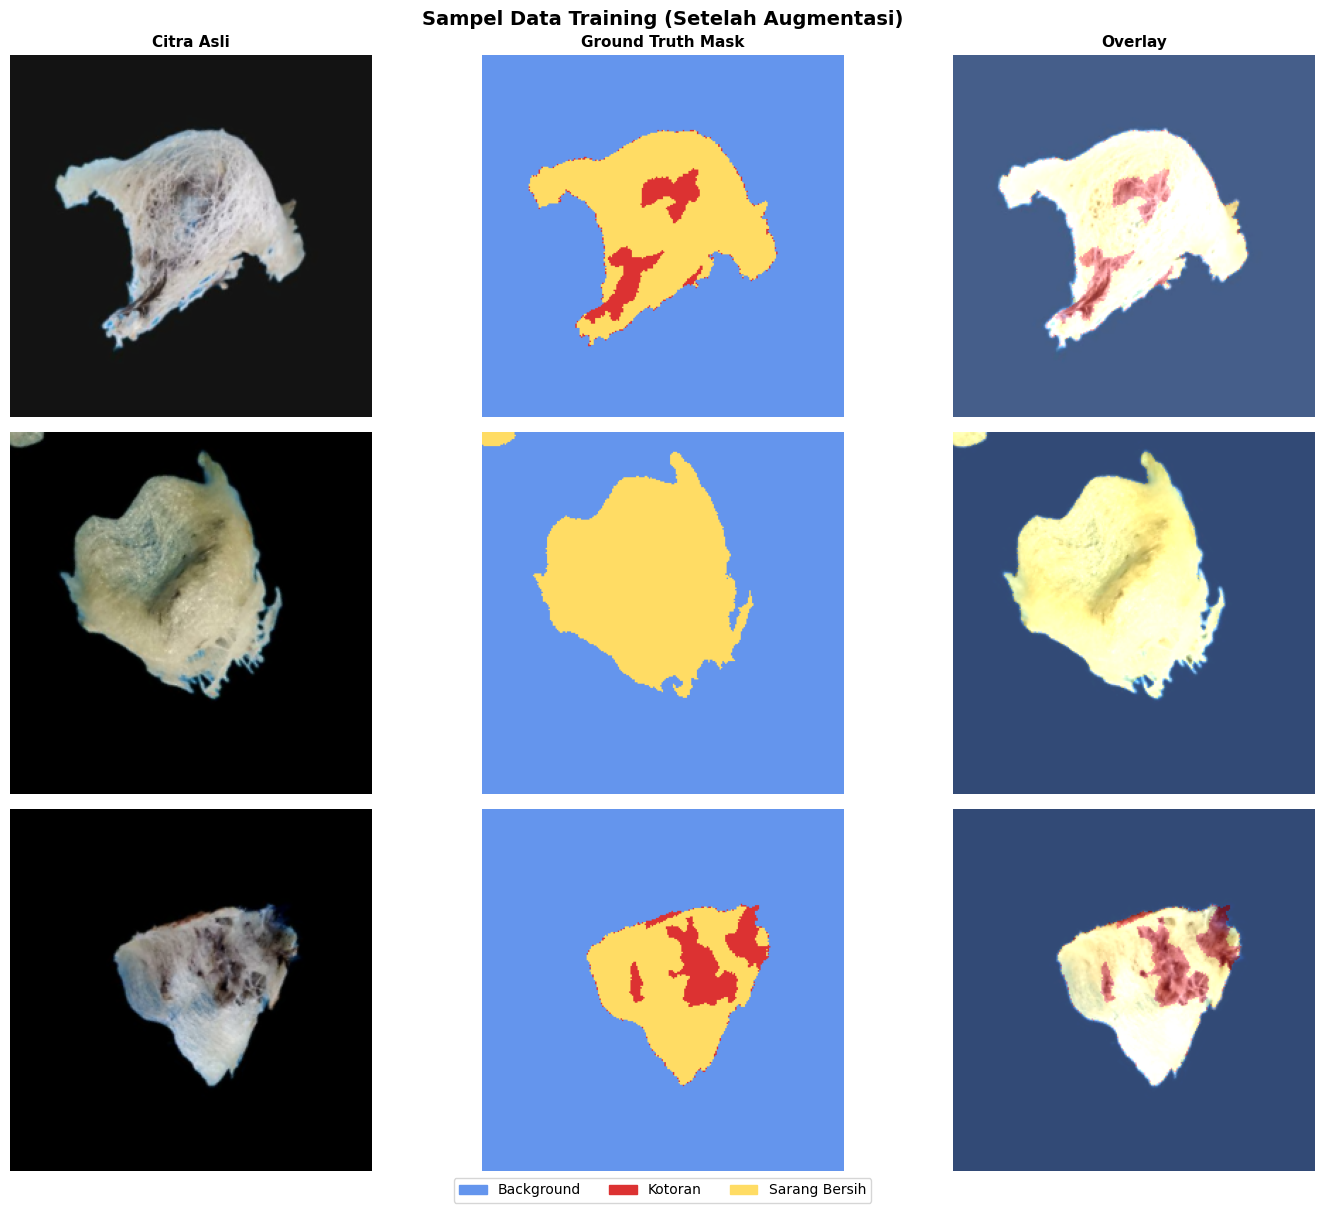

In [16]:
# menampilkan sampel data training beserta ground truth mask (setelah augmentasi)
n = 3
imgs, masks = next(iter(train_dataset.unbatch().batch(n).take(1)))
fig, axes = plt.subplots(n, 3, figsize=(15, n * 4))
fig.suptitle("Sampel Data Training (Setelah Augmentasi)", fontsize=14, fontweight='bold')

for ax, ct in zip(axes[0], ["Citra Asli", "Ground Truth Mask", "Overlay"]):
    ax.set_title(ct, fontsize=11, fontweight='bold')

for i in range(n):
    img  = imgs[i].numpy().astype(np.float32)  # ← Cast float16 ke float32 agar Matplotlib tidak error
    msk  = masks[i].numpy().squeeze()
    mrgb = mask_to_rgb(msk)
    axes[i][0].imshow(img);                axes[i][0].axis('off')
    axes[i][1].imshow(mrgb);               axes[i][1].axis('off')
    axes[i][2].imshow(overlay(img, mrgb)); axes[i][2].axis('off')

fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), fontsize=10)
plt.tight_layout()
plt.show()

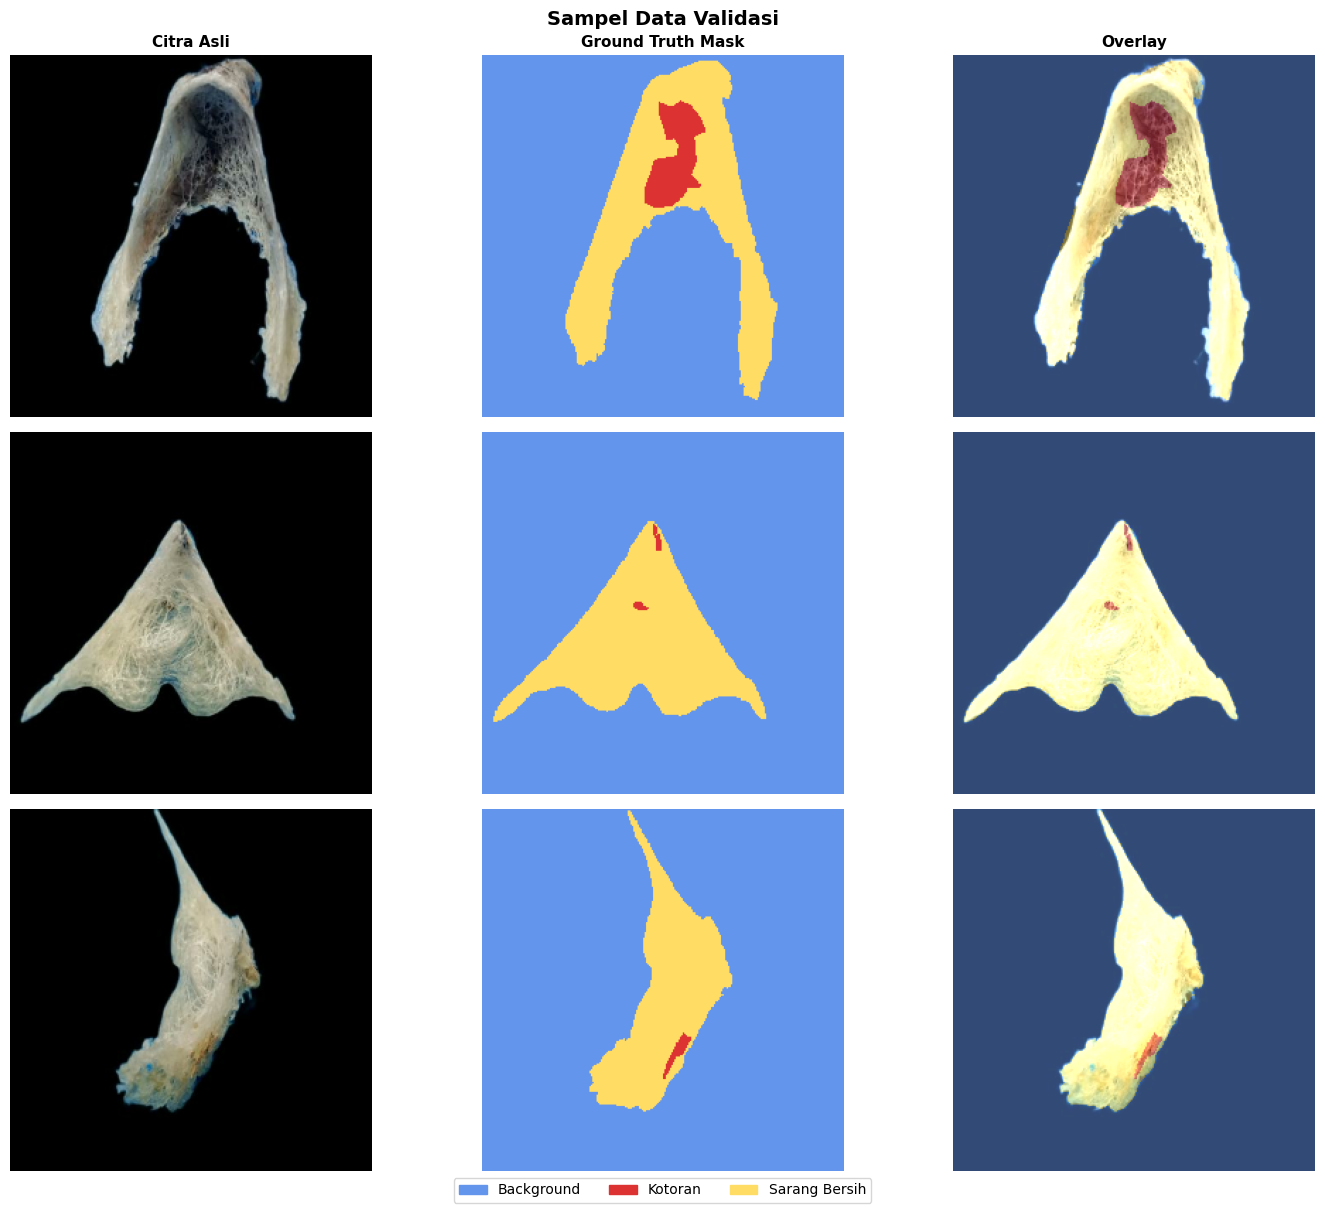

In [17]:
# menampilkan sampel data validasi
n = 3
imgs, masks = next(iter(valid_dataset.unbatch().batch(n).take(1)))
fig, axes = plt.subplots(n, 3, figsize=(15, n * 4))
fig.suptitle("Sampel Data Validasi", fontsize=14, fontweight='bold')

for ax, ct in zip(axes[0], ["Citra Asli", "Ground Truth Mask", "Overlay"]):
    ax.set_title(ct, fontsize=11, fontweight='bold')

for i in range(n):
    img  = imgs[i].numpy().astype(np.float32)  # ← Cast float16 ke float32 agar Matplotlib tidak error
    msk  = masks[i].numpy().squeeze()
    mrgb = mask_to_rgb(msk)
    axes[i][0].imshow(img);                axes[i][0].axis('off')
    axes[i][1].imshow(mrgb);               axes[i][1].axis('off')
    axes[i][2].imshow(overlay(img, mrgb)); axes[i][2].axis('off')

fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02), fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
# membangun model DeepLabV3+ dengan backbone ResNet50V2 (pretrained ImageNet)
backbone = keras_cv.models.ResNet50V2Backbone.from_preset(
    preset       = train_cfg.BACKBONE,
    input_shape  = data_cfg.IMAGE_SIZE + (3,),
    load_weights = True,
)

model = keras_cv.models.segmentation.DeepLabV3Plus(
    num_classes = data_cfg.NUM_CLASSES,
    backbone    = backbone,
)

model.build((None,) + data_cfg.IMAGE_SIZE + (3,))
model.summary(line_length=100)

Model: "deep_lab_v3_plus"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 256, 256, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ functional (Functional)     │ [(None, 64, 64, 256),   │     23,556,608 │ input_layer[0][0]       │
│                             │ (None, 8, 8, 2048)]     │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ spatial_pyramid_pooling     │ (None, 8, 8, 256)       │     15,538,176 │ functional[0][1]        │
│ (SpatialPyramidPooling)     │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ encoder_output_upsampling   │ (None, 64, 64, 256)     │              0 │ spatial_pyramid_poolin… │
│ (UpSampling2D)              │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ sequential_7 (Sequential)   │ (None, 64, 64, 48)      │         12,480 │ functional[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ concatenate (Concatenate)   │ (None, 64, 64, 304)     │              0 │ encoder_output_upsampl… │
│                             │                         │                │ sequential_7[0][0]      │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ sequential_8 (Sequential)   │ (None, 256, 256, 3)     │         79,616 │ concatenate[0][0]       │
└─────────────────────────────┴─────────────────────────┴────────────────┴─────────────────────────┘

 Total params: 39,186,880 (149.49 MB)

 Trainable params: 39,141,856 (149.31 MB)

 Non-trainable params: 45,024 (175.88 KB)

In [19]:
# mendefinisikan metrik Mean IoU untuk monitoring selama training
def mean_iou_metric(y_true, y_pred):
    num_classes  = y_pred.shape[-1] or data_cfg.NUM_CLASSES
    y_true_oh    = tf.one_hot(tf.cast(tf.squeeze(y_true, -1), tf.int32), num_classes)
    y_pred_oh    = tf.one_hot(tf.math.argmax(y_pred, -1), num_classes)
    intersection = tf.reduce_sum(y_true_oh * y_pred_oh, axis=(1, 2))
    total        = (tf.reduce_sum(y_true_oh, axis=(1, 2)) +
                    tf.reduce_sum(y_pred_oh, axis=(1, 2)))
    union        = total - intersection
    present      = tf.cast(tf.not_equal(total, 0), tf.float32)
    n_present    = tf.reduce_sum(present, axis=1)
    iou          = tf.math.divide_no_nan(intersection, union)
    iou          = tf.reduce_sum(iou * present, axis=1) / tf.maximum(n_present, 1)
    return tf.reduce_mean(iou)

mean_iou_metric.__name__ = "mean_iou_metric"
print("Metrik Mean IoU berhasil didefinisikan.")

Metrik Mean IoU berhasil didefinisikan.


In [20]:
# compile model dengan Weighted Cross-Entropy Loss

CLASS_WEIGHTS_LIST = [1.0, 9.0, 5.0]

def weighted_sparse_crossentropy(class_weights=CLASS_WEIGHTS_LIST):
    weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        # cast ke float32 eksplisit agar kompatibel dengan mixed precision
        y_pred    = tf.cast(y_pred, tf.float32)
        y_true_sq = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
        pixel_weights = tf.gather(weights_tensor, y_true_sq)
        ce_loss = tf.keras.losses.sparse_categorical_crossentropy(
            y_true_sq, y_pred, from_logits=False
        )
        return tf.reduce_mean(ce_loss * pixel_weights)
    loss_fn.__name__ = "weighted_sparse_crossentropy"
    return loss_fn

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=train_cfg.LEARNING_RATE),
    loss      = weighted_sparse_crossentropy(CLASS_WEIGHTS_LIST),
    metrics   = ["accuracy", mean_iou_metric],
)

print("Model berhasil di-compile.")
print(f"Optimizer     : Adam (lr={train_cfg.LEARNING_RATE})")
print(f"Loss          : Weighted Sparse Categorical Crossentropy")
print(f"Class Weights : Background={CLASS_WEIGHTS_LIST[0]}, Kotoran={CLASS_WEIGHTS_LIST[1]}, Sarang Bersih={CLASS_WEIGHTS_LIST[2]}")
print(f"Metrics       : accuracy, mean_iou_metric")

Model berhasil di-compile.
Optimizer     : Adam (lr=0.0001)
Loss          : Weighted Sparse Categorical Crossentropy
Class Weights : Background=1.0, Kotoran=9.0, Sarang Bersih=5.0
Metrics       : accuracy, mean_iou_metric


In [21]:
# menampilkan estimasi penggunaan VRAM setelah optimasi
print("=" * 55)
print("  ESTIMASI PENGGUNAAN VRAM SETELAH OPTIMASI")
print("=" * 55)
print(f"  IMAGE_SIZE      : {data_cfg.IMAGE_SIZE}  (dari 512x512)")
print(f"  BATCH_SIZE      : {data_cfg.BATCH_SIZE}")
print(f"  Mixed Precision : float16 (aktif)")
print(f"  Est. VRAM       : ~7-9 GB  (T4 Colab: 15 GB)")
print(f"  Status          : Aman untuk T4 Google Colab")
print("=" * 55)

# cek GPU yang tersedia
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    print(f"  GPU ditemukan   : {gpu.name}")

  ESTIMASI PENGGUNAAN VRAM SETELAH OPTIMASI
  IMAGE_SIZE      : (256, 256)  (dari 512x512)
  BATCH_SIZE      : 8
  Mixed Precision : float16 (aktif)
  Est. VRAM       : ~7-9 GB  (T4 Colab: 15 GB)
  Status          : Aman untuk T4 Google Colab
  GPU ditemukan   : /physical_device:GPU:0


In [22]:
# mendefinisikan callbacks pelatihan
callbacks = [
    tf.keras.callbacks.TensorBoard(
        log_dir        = LOGS_DIR,
        histogram_freq = 10,
        write_graph    = False,
        update_freq    = "epoch",
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath          = CKPT_PATH,
        save_weights_only = True,
        monitor           = "val_mean_iou_metric",
        mode              = "max",
        save_best_only    = True,
        verbose           = 1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor   = "val_loss",
        factor    = 0.5,
        patience  = 7,
        min_lr    = 1e-7,
        verbose   = 1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_mean_iou_metric",
        mode                 = "max",
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1,
    ),
]

print(f"Callbacks: {[type(c).__name__ for c in callbacks]}")

Callbacks: ['TensorBoard', 'ModelCheckpoint', 'ReduceLROnPlateau', 'EarlyStopping']


In [23]:
# melatih model
print("=" * 60)
print("   Memulai Pelatihan Model DeepLabV3+")
print("=" * 60)
print(f"  Backbone      : {train_cfg.BACKBONE}")
print(f"  Image Size    : {data_cfg.IMAGE_SIZE}")
print(f"  Batch Size    : {data_cfg.BATCH_SIZE}")
print(f"  Epochs        : {train_cfg.EPOCHS}")
print(f"  Learning Rate : {train_cfg.LEARNING_RATE}")
print(f"  Num Classes   : {data_cfg.NUM_CLASSES}")
print(f"  Class Weights : {dict(enumerate(CLASS_WEIGHTS_LIST))}")
print(f"  Mixed Prec.   : float16")
print("=" * 60)

history = model.fit(
    train_dataset,
    epochs          = train_cfg.EPOCHS,
    validation_data = valid_dataset,
    callbacks       = callbacks,
)

   Memulai Pelatihan Model DeepLabV3+
  Backbone      : resnet50_v2_imagenet
  Image Size    : (256, 256)
  Batch Size    : 8
  Epochs        : 100
  Learning Rate : 0.0001
  Num Classes   : 3
  Class Weights : {0: 1.0, 1: 9.0, 2: 5.0}
  Mixed Prec.   : float16
Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5449 - loss: 1.8974 - mean_iou_metric: 0.3036
Epoch 1: val_mean_iou_metric improved from None to 0.09139, saving model to /content/drive/MyDrive/Skripsi (1)/Hasil_B8_E100_LR0.0001/best_deeplabv3plus.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi (1)/Hasil_B8_E100_LR0.0001/best_deeplabv3plus.weights.h5
60/60 ━━━━━━━━━━━━━━━━━━━━ 96s 786ms/step - accuracy: 0.7494 - loss: 1.3152 - mean_iou_metric: 0.4516 - val_accuracy: 0.2394 - val_loss: 4.4627 - val_mean_iou_metric: 0.0914 - learning_rate: 1.0000e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9363 - loss: 0.6292 - mean_iou_metric: 0.6340
Epoch 2: val_mean_iou_m

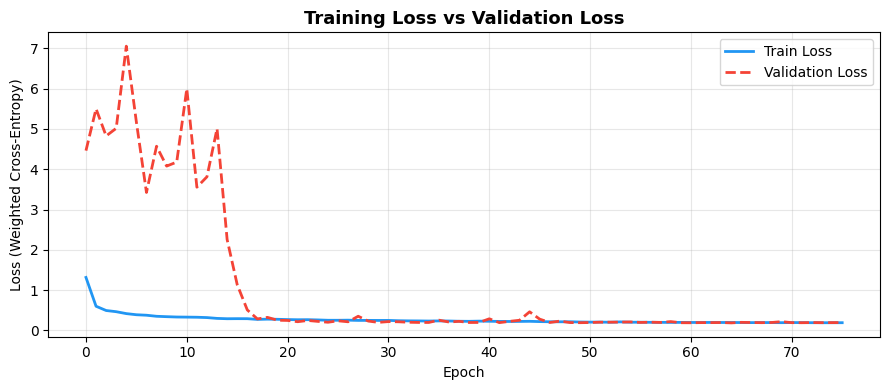

In [24]:
# menampilkan grafik training loss dan validation loss
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Train Loss',      linewidth=2, color='#2196F3')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#F44336',
         linestyle='--')
plt.title('Training Loss vs Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (Weighted Cross-Entropy)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_loss.png", dpi=150, bbox_inches='tight')
plt.show()

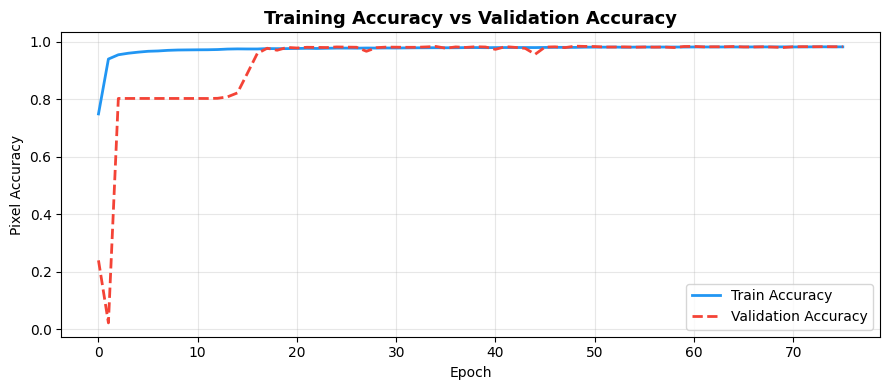

In [25]:
# menampilkan grafik training accuracy dan validation accuracy
plt.figure(figsize=(9, 4))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      linewidth=2, color='#2196F3')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#F44336',
         linestyle='--')
plt.title('Training Accuracy vs Validation Accuracy', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Pixel Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

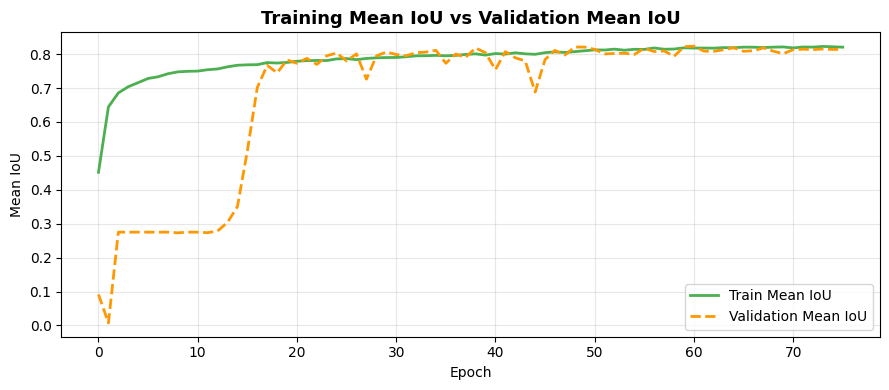

In [26]:
# menampilkan grafik training mean IoU dan validation mean IoU
plt.figure(figsize=(9, 4))
plt.plot(history.history['mean_iou_metric'],     label='Train Mean IoU',      linewidth=2, color='#4CAF50')
plt.plot(history.history['val_mean_iou_metric'], label='Validation Mean IoU', linewidth=2, color='#FF9800',
         linestyle='--')
plt.title('Training Mean IoU vs Validation Mean IoU', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Mean IoU')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plot_mean_iou.png", dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# memuat bobot model terbaik dari checkpoint
model.load_weights(CKPT_PATH)
print(f"Bobot terbaik dimuat dari: {CKPT_PATH}")

Bobot terbaik dimuat dari: /content/drive/MyDrive/Skripsi (1)/Hasil_B8_E100_LR0.0001/best_deeplabv3plus.weights.h5


In [28]:
# mendefinisikan fungsi evaluasi model menggunakan confusion matrix
def compute_metrics(model, dataset, num_classes=data_cfg.NUM_CLASSES):
    cm_total = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in dataset:
        preds       = model.predict(images, verbose=0)
        # cast ke float32 sebelum argmax (output mixed precision bisa float16)
        preds       = preds.astype(np.float32)
        pred_labels = np.argmax(preds, axis=-1)
        true_labels = masks.numpy().squeeze(axis=-1).astype(int)
        cm = confusion_matrix(
            true_labels.ravel(), pred_labels.ravel(),
            labels=list(range(num_classes))
        )
        cm_total += cm

    results = {"confusion_matrix": cm_total}
    results["pixel_accuracy"] = np.trace(cm_total) / cm_total.sum()

    iou_list, prec_list, rec_list, f1_list = [], [], [], []

    for c in range(num_classes):
        tp = cm_total[c, c]
        fp = cm_total[:, c].sum() - tp
        fn = cm_total[c, :].sum() - tp

        iou  = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0
        prec = tp / (tp + fp)      if (tp + fp)      > 0 else 0.0
        rec  = tp / (tp + fn)      if (tp + fn)      > 0 else 0.0
        f1   = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

        iou_list .append(iou)
        prec_list.append(prec)
        rec_list .append(rec)
        f1_list  .append(f1)

    results["iou_per_class"]       = iou_list
    results["mean_iou"]            = np.mean(iou_list)
    results["precision_per_class"] = prec_list
    results["mean_precision"]      = np.mean(prec_list)
    results["recall_per_class"]    = rec_list
    results["mean_recall"]         = np.mean(rec_list)
    results["f1_per_class"]        = f1_list
    results["mean_f1"]             = np.mean(f1_list)
    return results

print("Fungsi evaluasi siap.")

Fungsi evaluasi siap.


In [29]:
# mengevaluasi model pada validation set
print("Mengevaluasi pada Validation Set...")
val_results = compute_metrics(model, valid_dataset)

print("\n" + "=" * 62)
print("  Hasil Evaluasi — Validation Set")
print("=" * 62)
print(f"  Pixel Accuracy  : {val_results['pixel_accuracy']:.4f}  ({val_results['pixel_accuracy']*100:.2f}%)")
print(f"  Mean IoU        : {val_results['mean_iou']:.4f}  ({val_results['mean_iou']*100:.2f}%)")
print(f"  Mean Precision  : {val_results['mean_precision']:.4f}")
print(f"  Mean Recall     : {val_results['mean_recall']:.4f}")
print(f"  Mean F1-Score   : {val_results['mean_f1']:.4f}")
print()
print(f"  {'Kelas':<20} {'IoU':>8} {'Precision':>10} {'Recall':>8} {'F1-Score':>10}")
print(f"  {'-'*60}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<20} "
          f"{val_results['iou_per_class'][i]:>8.4f} "
          f"{val_results['precision_per_class'][i]:>10.4f} "
          f"{val_results['recall_per_class'][i]:>8.4f} "
          f"{val_results['f1_per_class'][i]:>10.4f}")

Mengevaluasi pada Validation Set...

  Hasil Evaluasi — Validation Set
  Pixel Accuracy  : 0.9844  (98.44%)
  Mean IoU        : 0.8501  (85.01%)
  Mean Precision  : 0.9078
  Mean Recall     : 0.9148
  Mean F1-Score   : 0.9113

  Kelas                     IoU  Precision   Recall   F1-Score
  ------------------------------------------------------------
  Background             0.9917     0.9989   0.9928     0.9958
  Kotoran                0.6394     0.7796   0.7806     0.7801
  Sarang Bersih          0.9193     0.9451   0.9711     0.9579


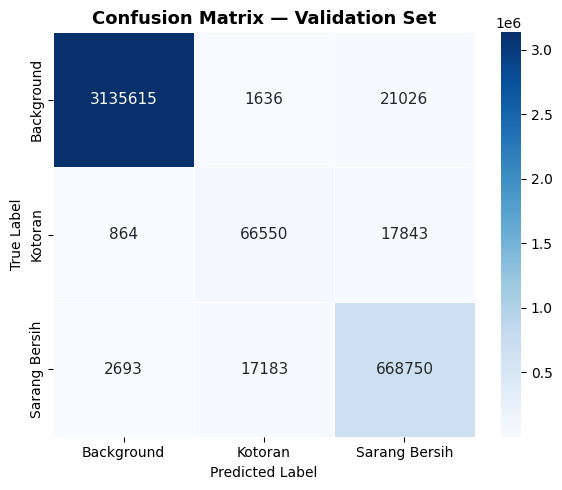

In [30]:
# menampilkan confusion matrix pada validation set
cm_val = val_results['confusion_matrix']
df_cm  = pd.DataFrame(cm_val, index=CLASS_NAMES, columns=CLASS_NAMES)

plt.figure(figsize=(6, 5))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, annot_kws={"size": 11})
plt.title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cm_validation.png", dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# mengevaluasi model pada test set
print("Mengevaluasi pada Test Set...")
test_results = compute_metrics(model, test_dataset)

label = 'Test Set' if HAS_TEST else 'Test Set (= Validation)'
print(f"\n" + "=" * 62)
print(f"  Hasil Evaluasi — {label}")
print("=" * 62)
print(f"  Pixel Accuracy  : {test_results['pixel_accuracy']:.4f}  ({test_results['pixel_accuracy']*100:.2f}%)")
print(f"  Mean IoU        : {test_results['mean_iou']:.4f}  ({test_results['mean_iou']*100:.2f}%)")
print(f"  Mean Precision  : {test_results['mean_precision']:.4f}")
print(f"  Mean Recall     : {test_results['mean_recall']:.4f}")
print(f"  Mean F1-Score   : {test_results['mean_f1']:.4f}")
print()
print(f"  {'Kelas':<20} {'IoU':>8} {'Precision':>10} {'Recall':>8} {'F1-Score':>10}")
print(f"  {'-'*60}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<20} "
          f"{test_results['iou_per_class'][i]:>8.4f} "
          f"{test_results['precision_per_class'][i]:>10.4f} "
          f"{test_results['recall_per_class'][i]:>8.4f} "
          f"{test_results['f1_per_class'][i]:>10.4f}")

Mengevaluasi pada Test Set...

  Hasil Evaluasi — Test Set (= Validation)
  Pixel Accuracy  : 0.9844  (98.44%)
  Mean IoU        : 0.8501  (85.01%)
  Mean Precision  : 0.9078
  Mean Recall     : 0.9148
  Mean F1-Score   : 0.9113

  Kelas                     IoU  Precision   Recall   F1-Score
  ------------------------------------------------------------
  Background             0.9917     0.9989   0.9928     0.9958
  Kotoran                0.6394     0.7796   0.7806     0.7801
  Sarang Bersih          0.9193     0.9451   0.9711     0.9579


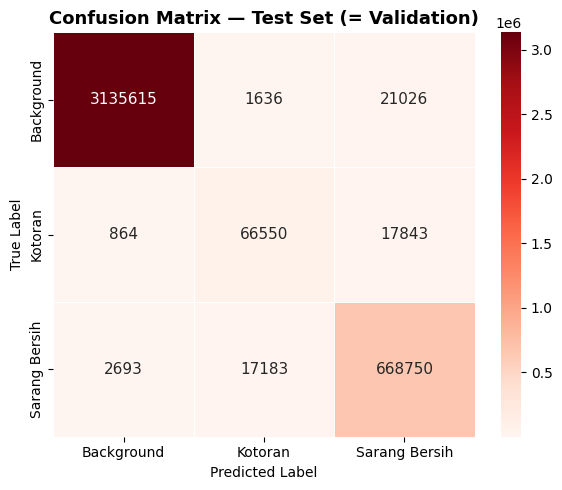

In [32]:
# menampilkan confusion matrix pada test set
cm_test    = test_results['confusion_matrix']
df_cm_test = pd.DataFrame(cm_test, index=CLASS_NAMES, columns=CLASS_NAMES)
label      = 'Test Set' if HAS_TEST else 'Test Set (= Validation)'

plt.figure(figsize=(6, 5))
sns.heatmap(df_cm_test, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, annot_kws={"size": 11})
plt.title(f'Confusion Matrix — {label}', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cm_test.png", dpi=150, bbox_inches='tight')
plt.show()

Menampilkan seluruh hasil prediksi gambar validasi...
Gunakan hasil ini untuk membandingkan Label Asli vs Prediksi Model.


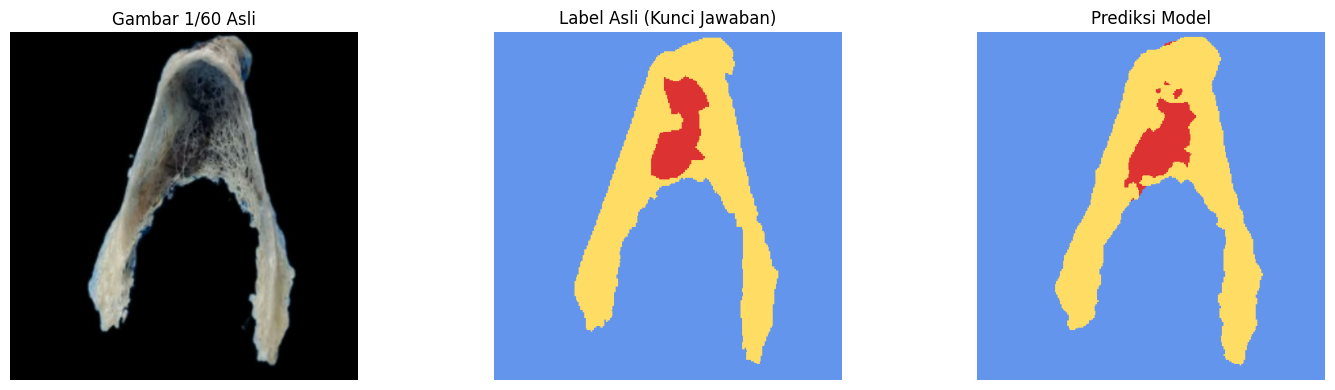

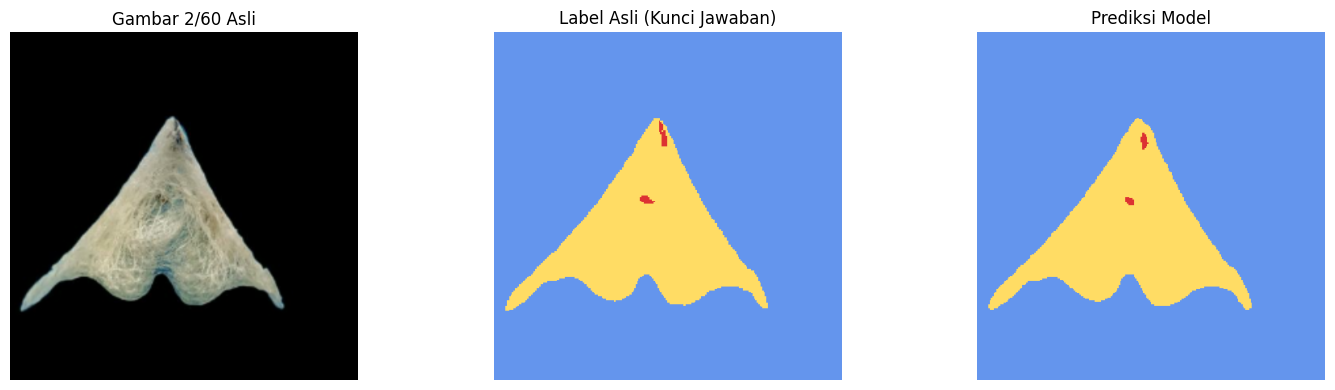

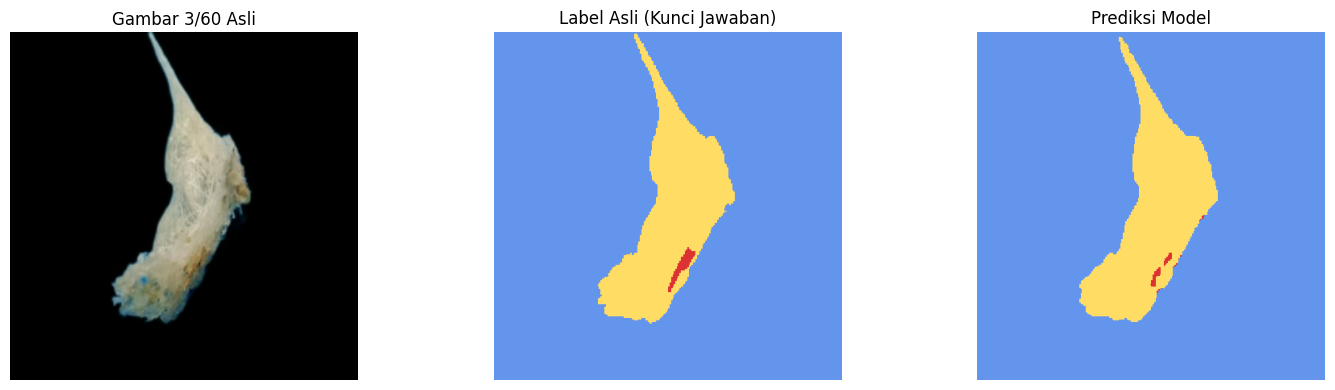

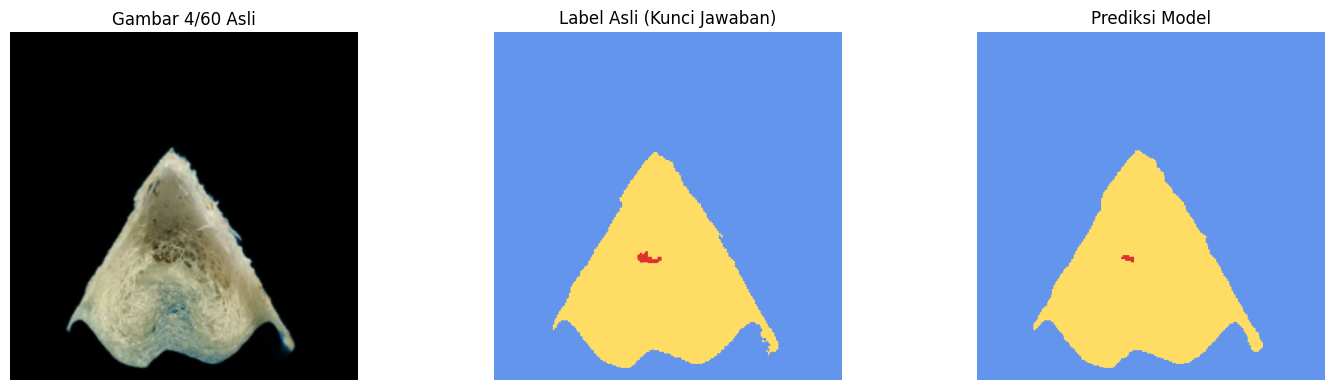

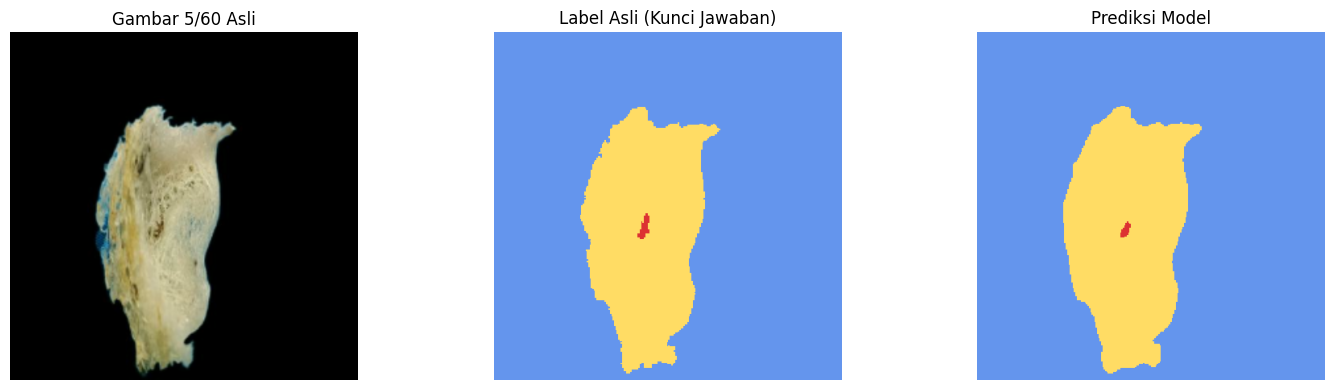

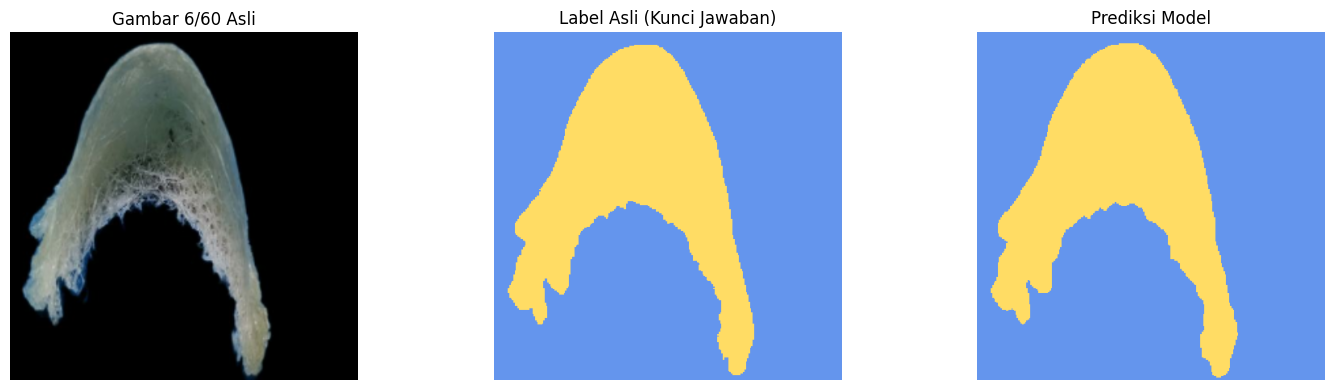

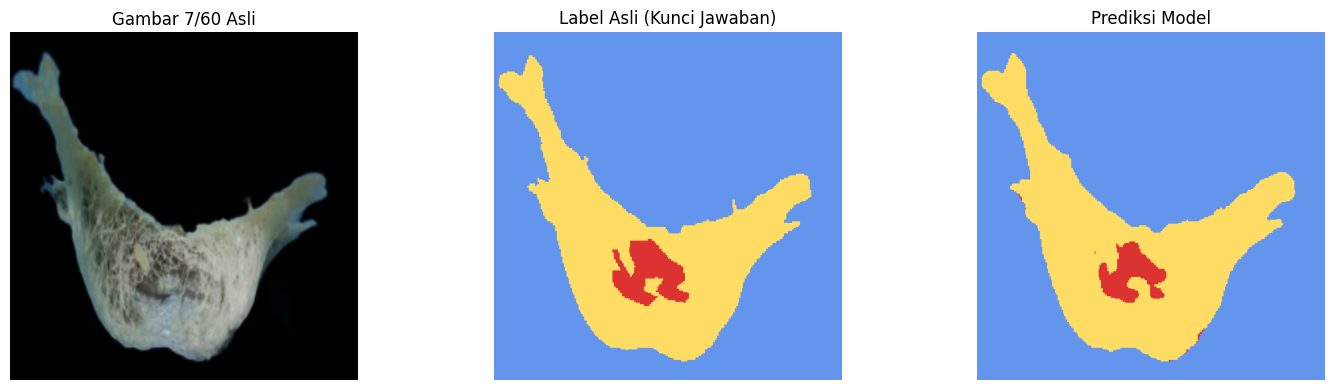

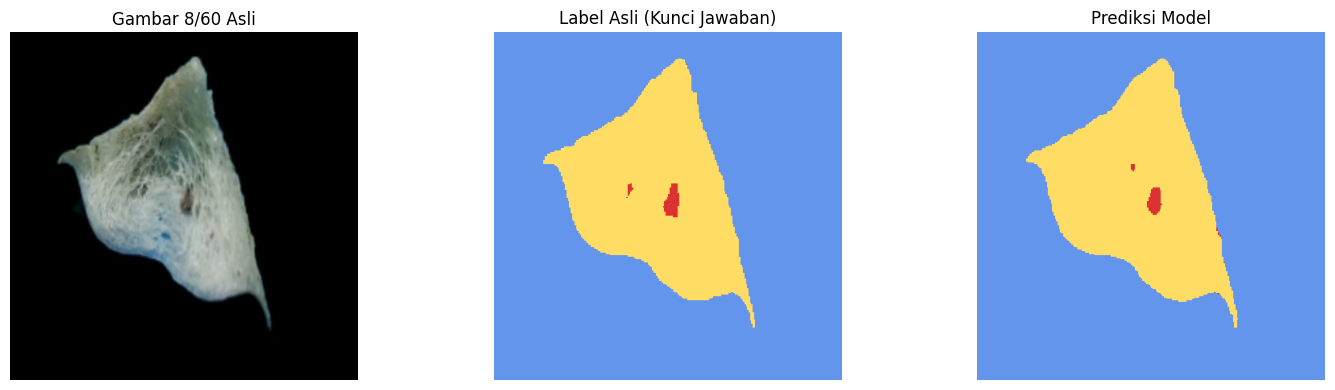

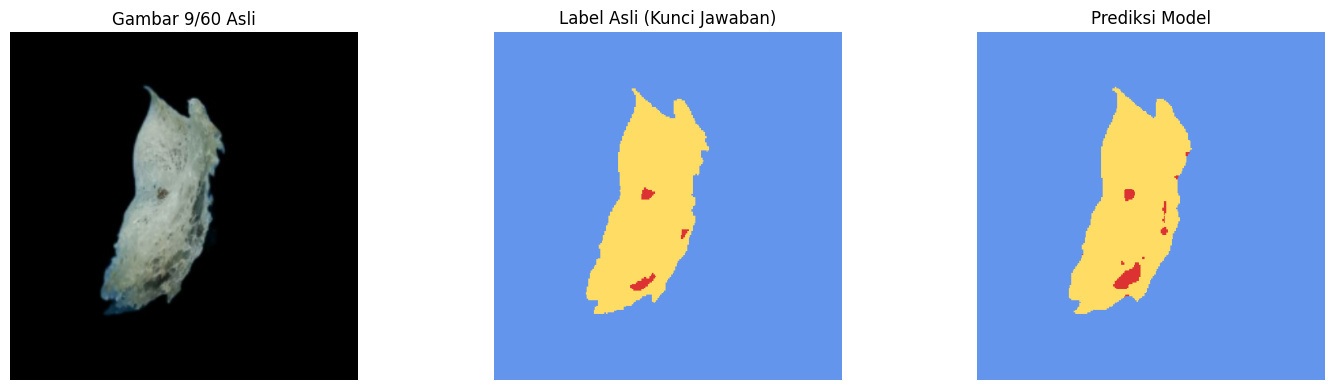

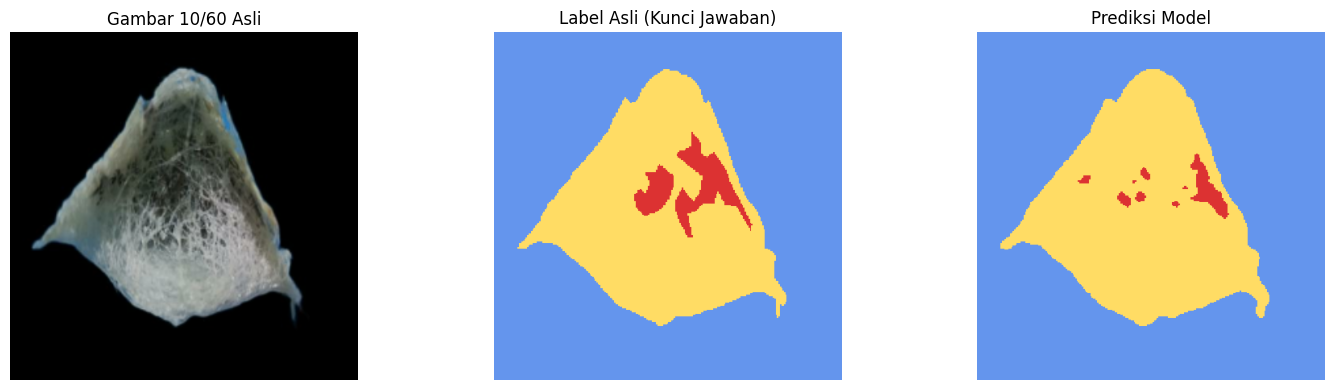

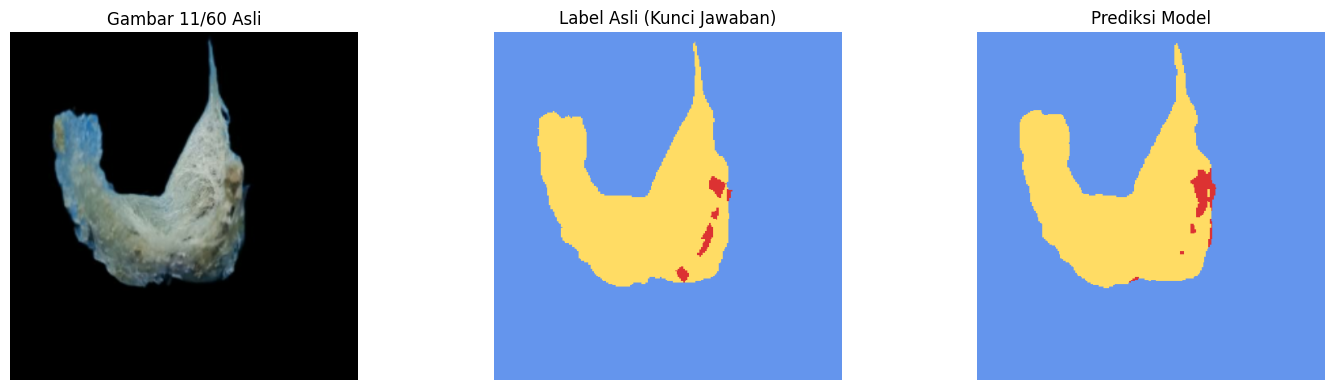

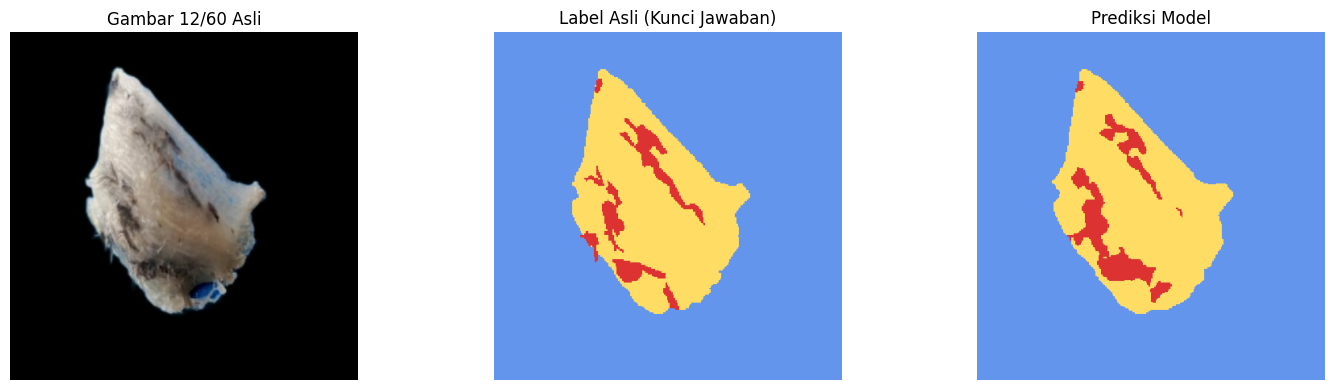

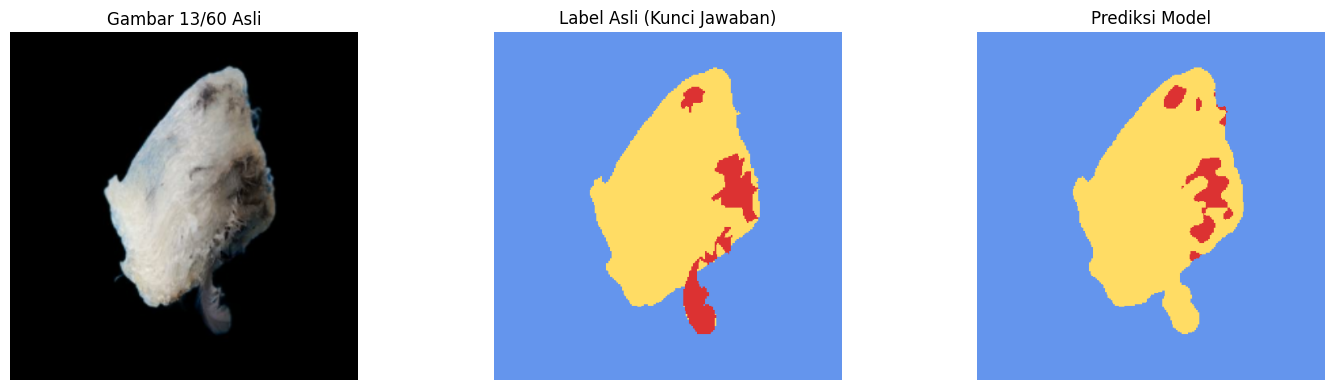

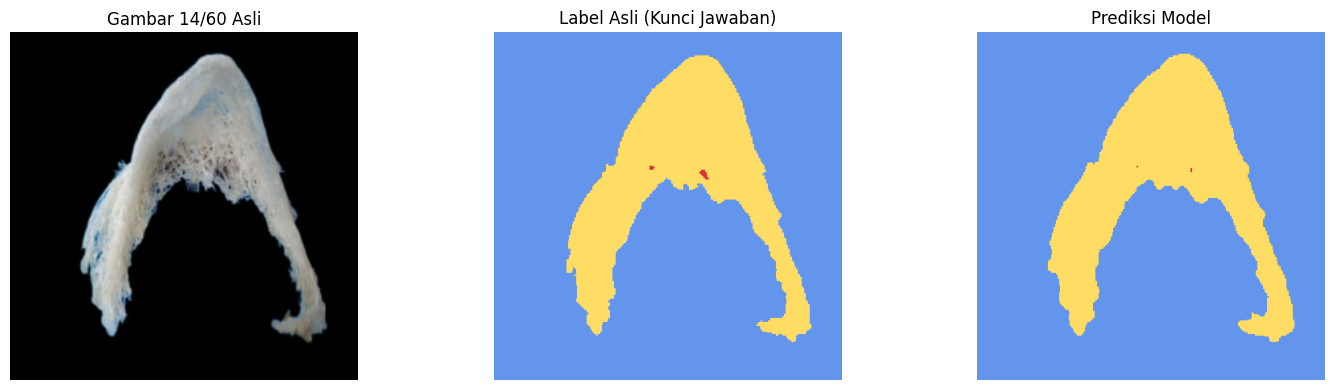

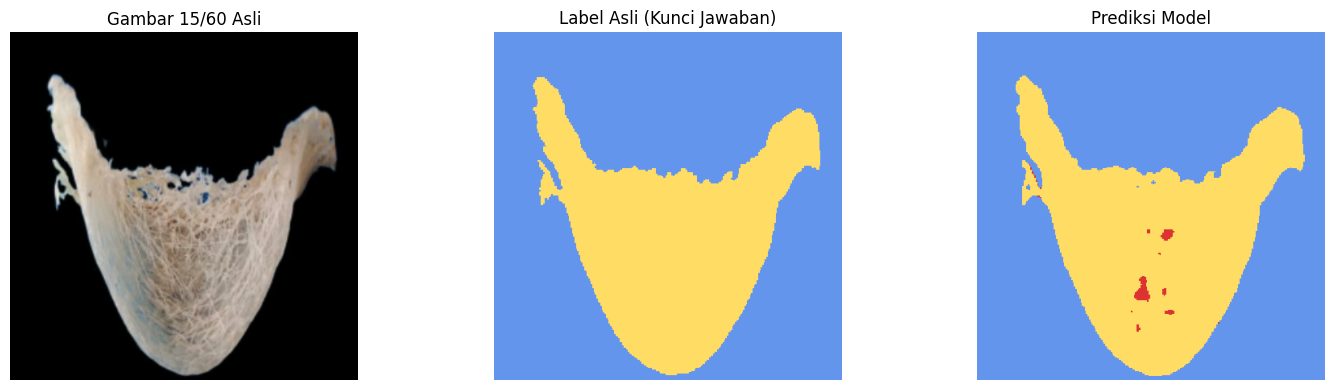

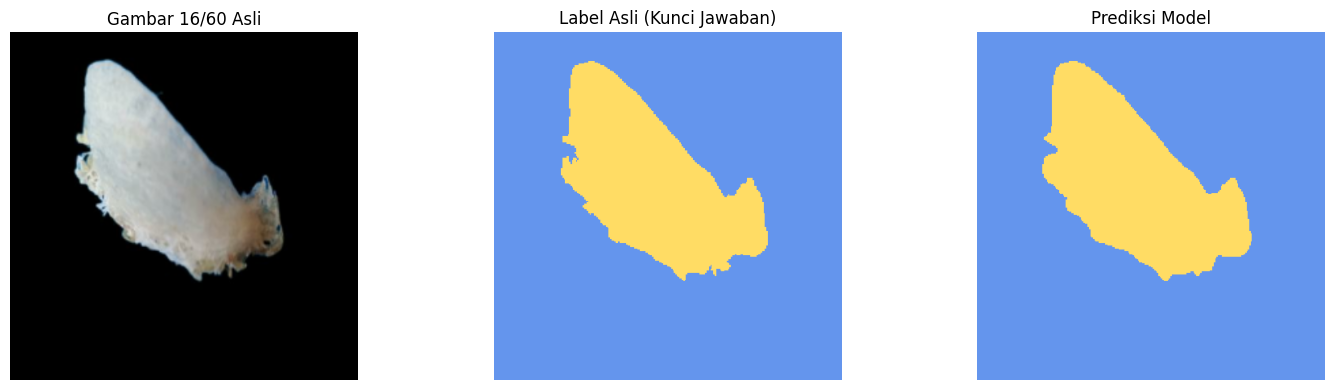

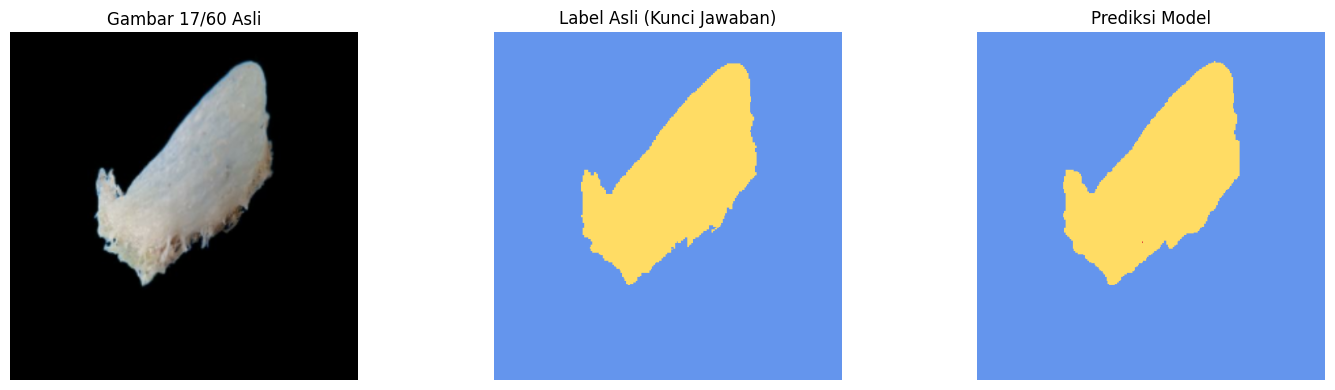

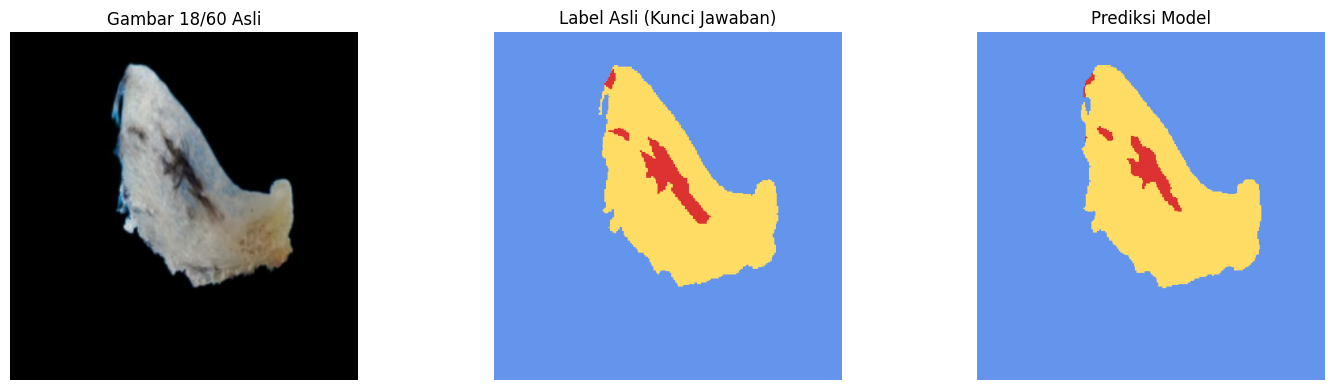

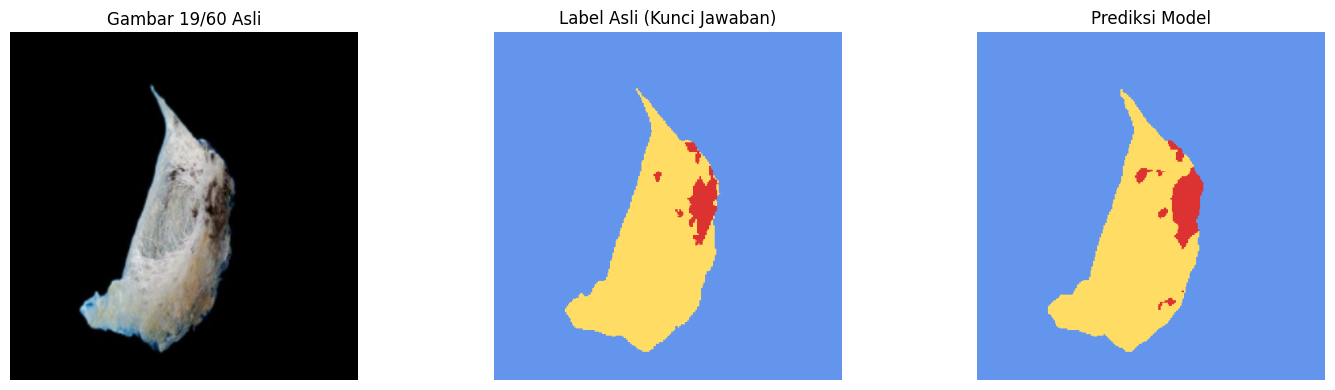

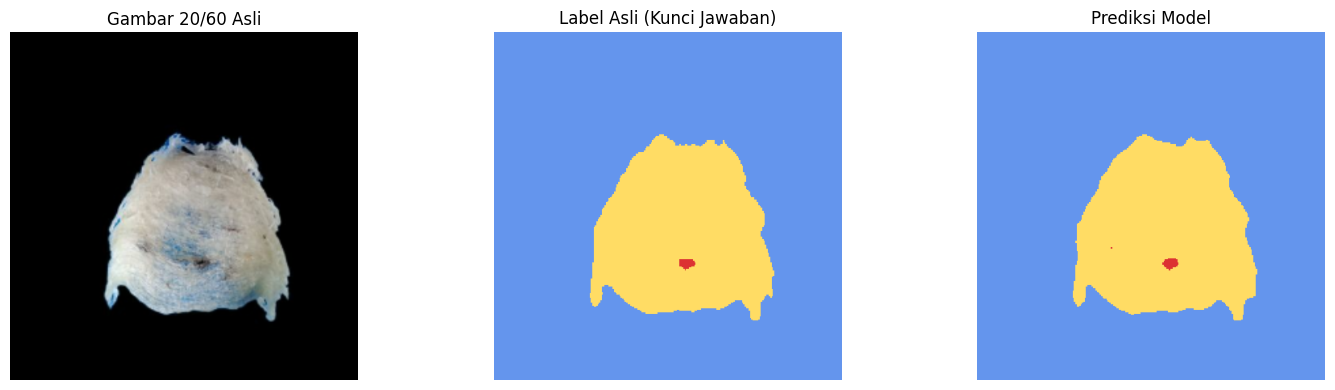

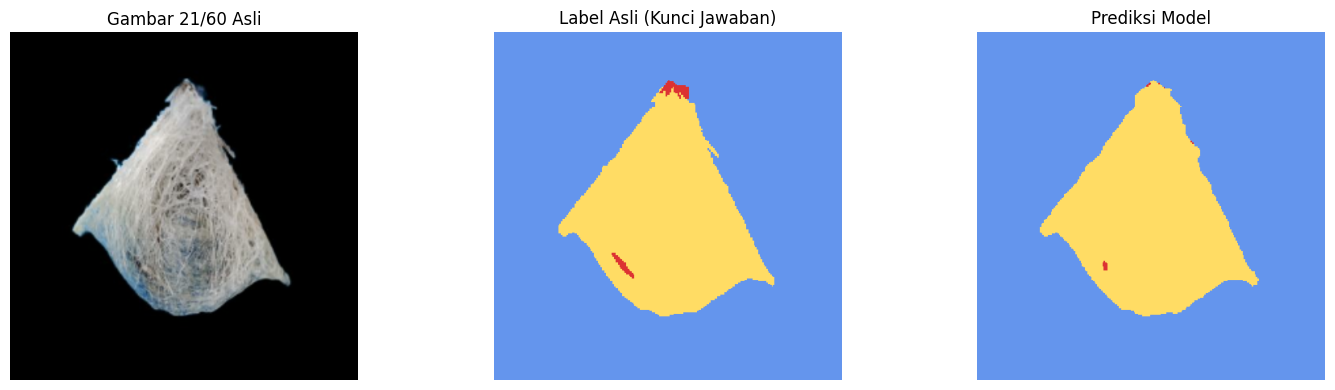

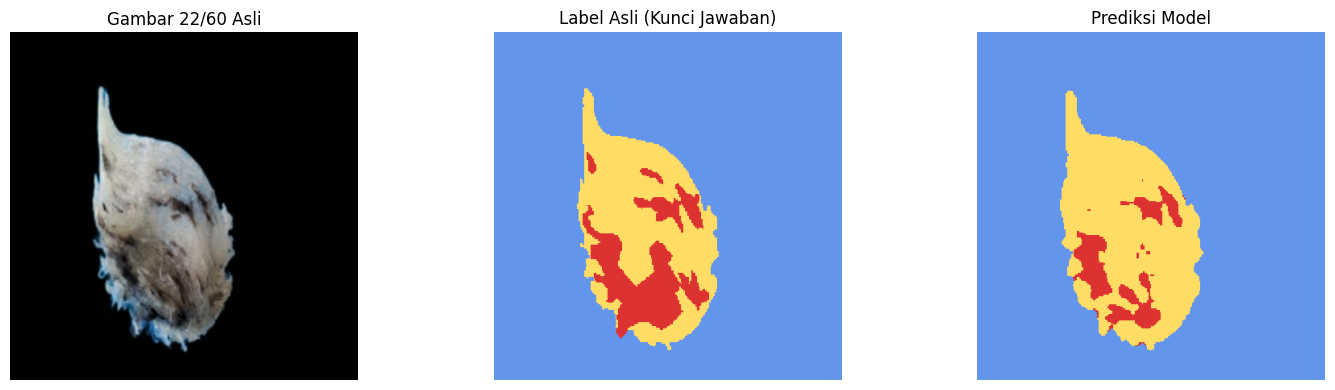

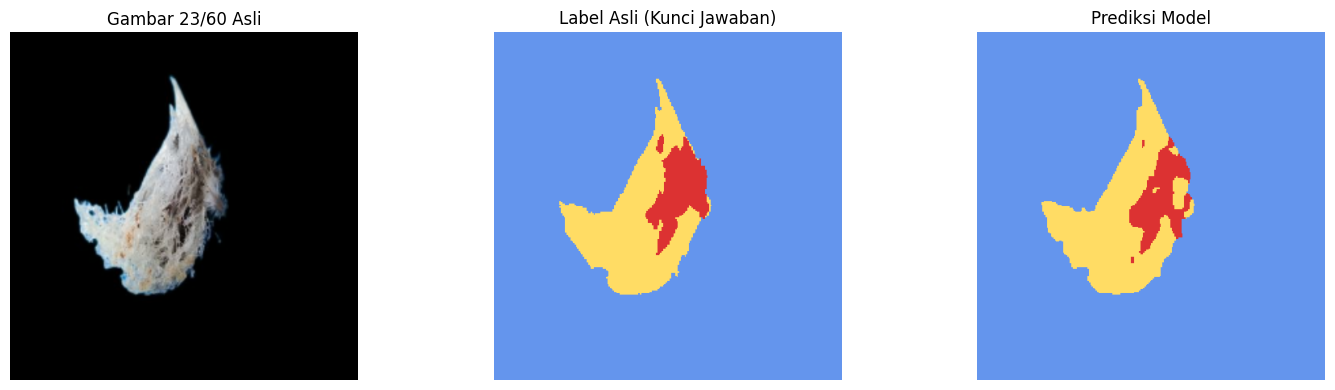

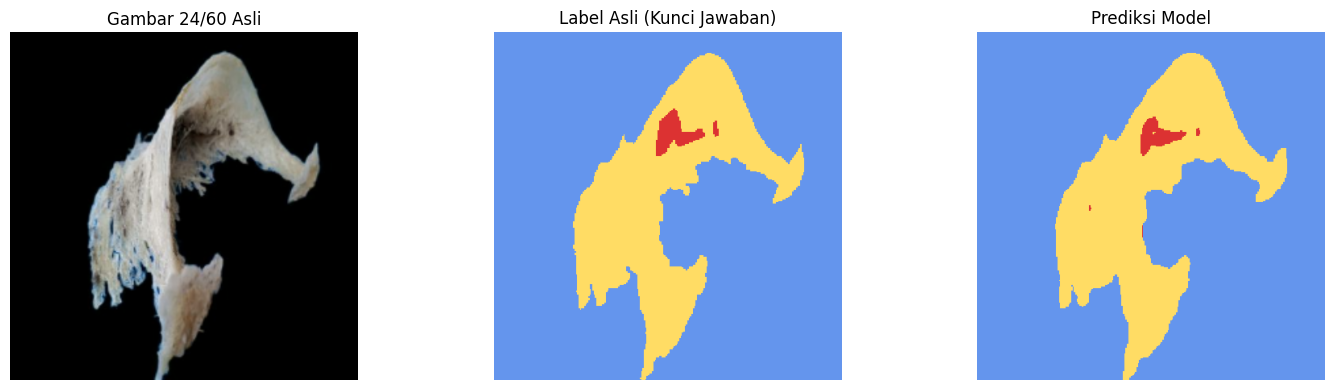

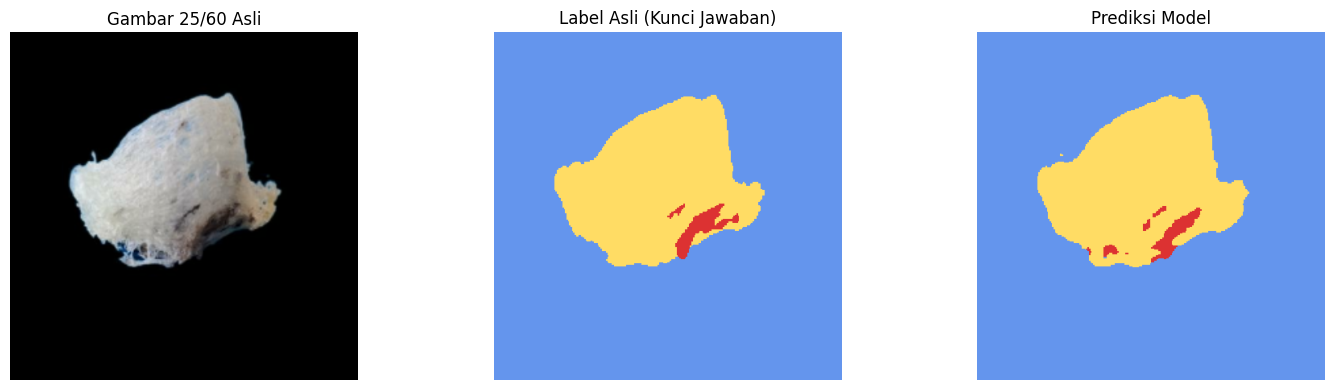

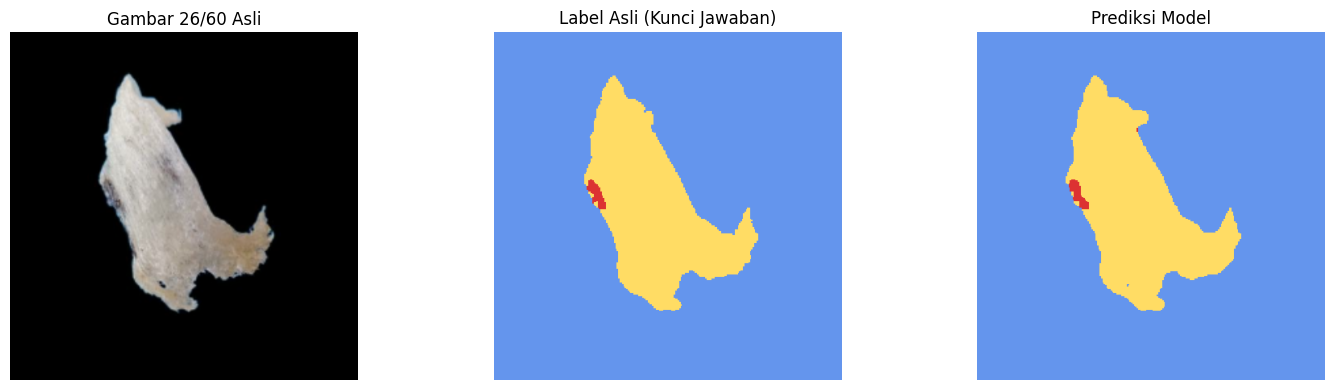

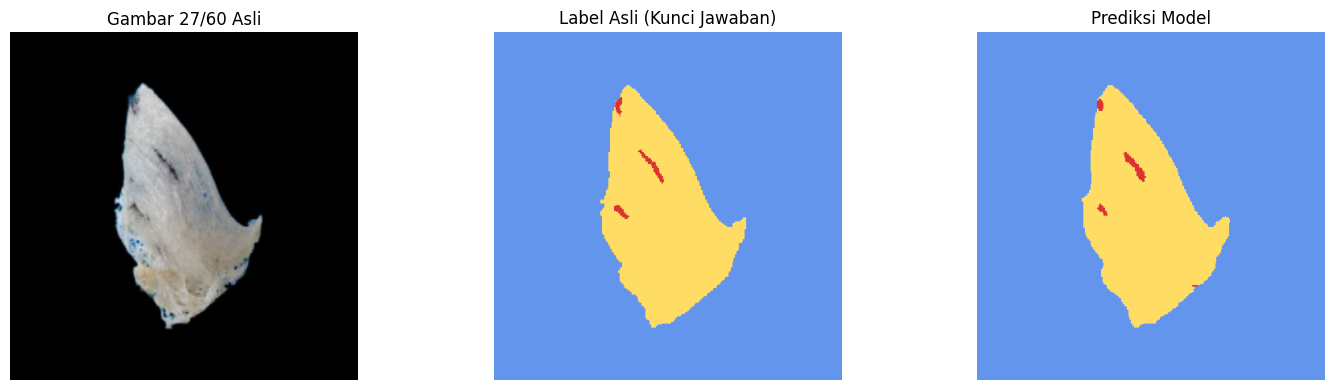

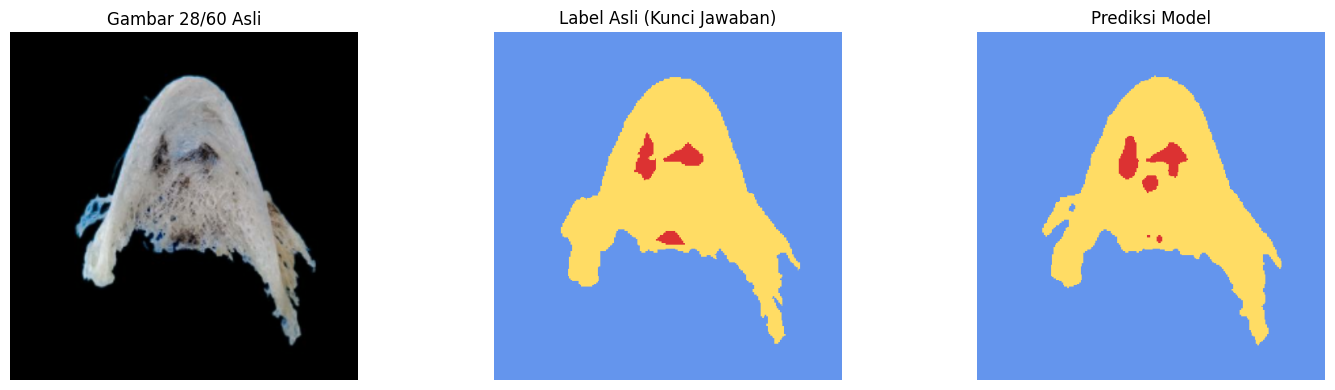

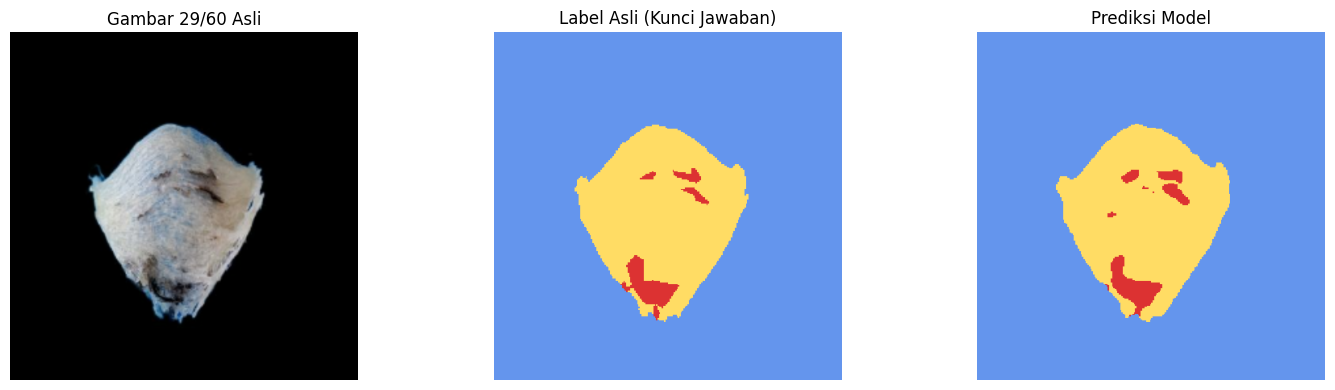

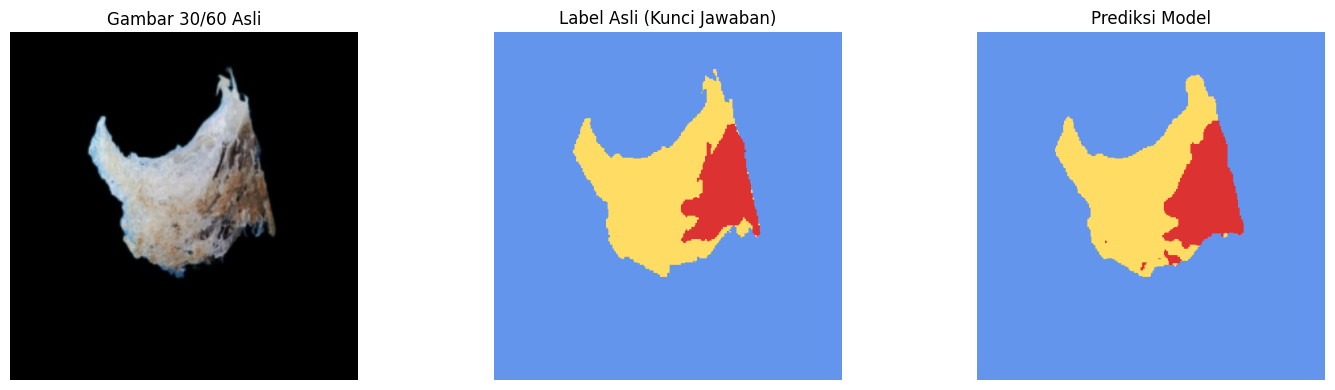

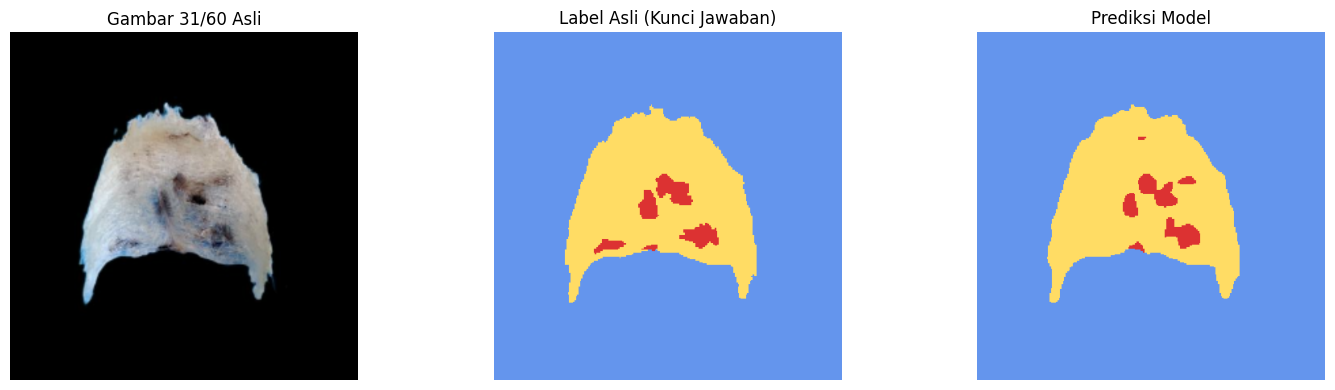

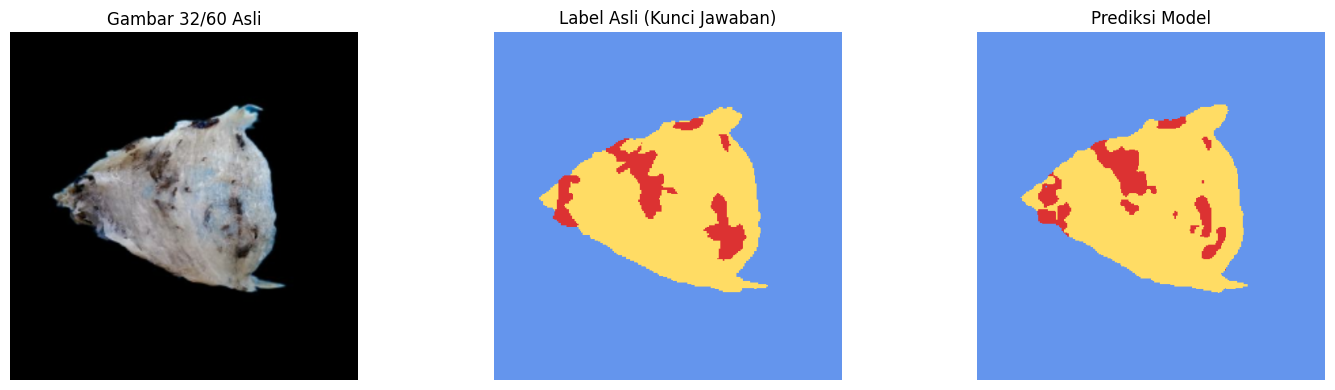

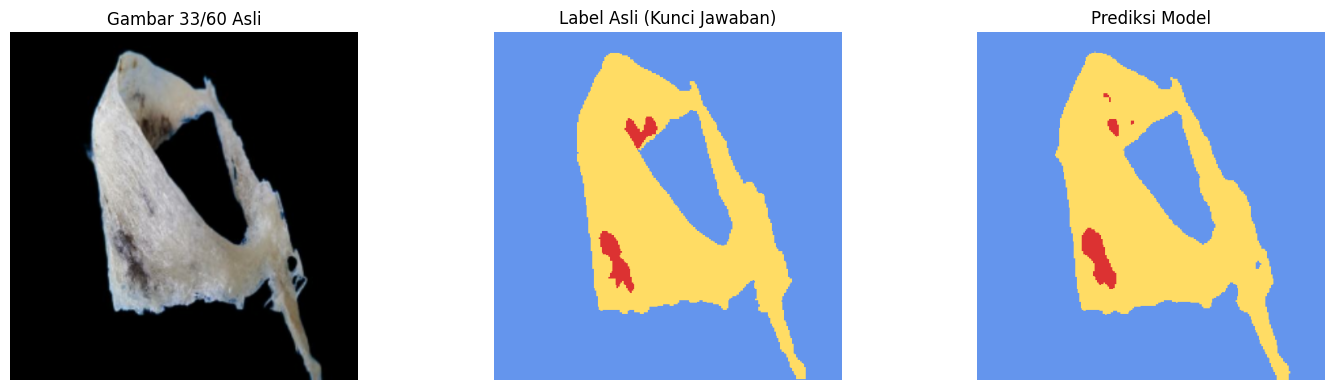

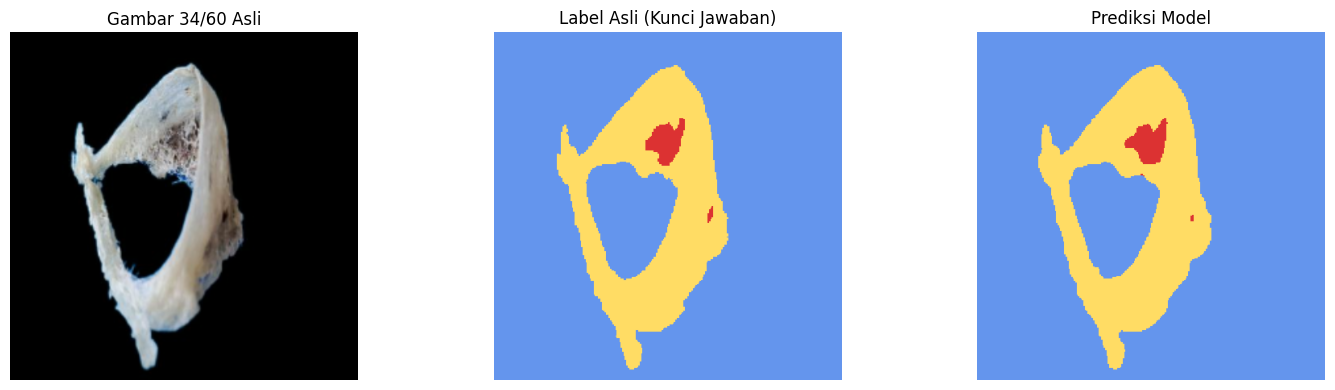

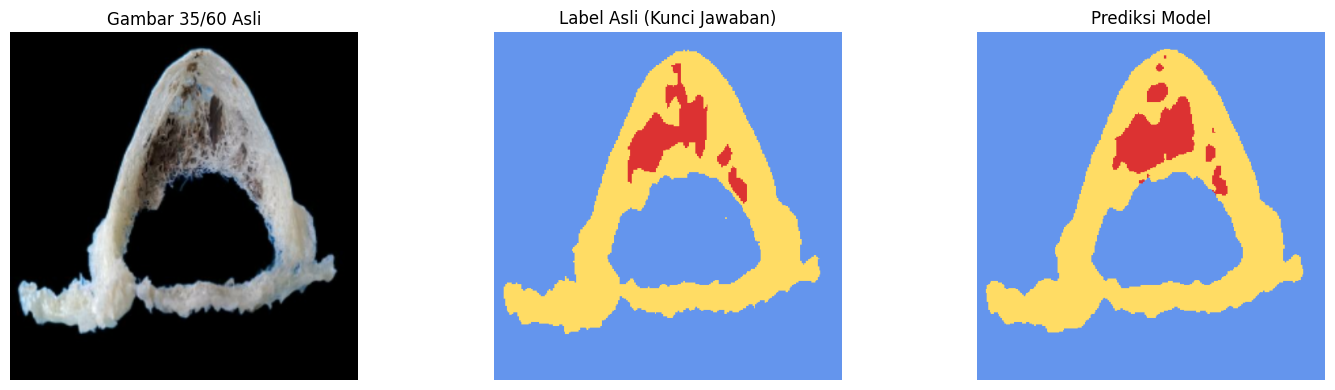

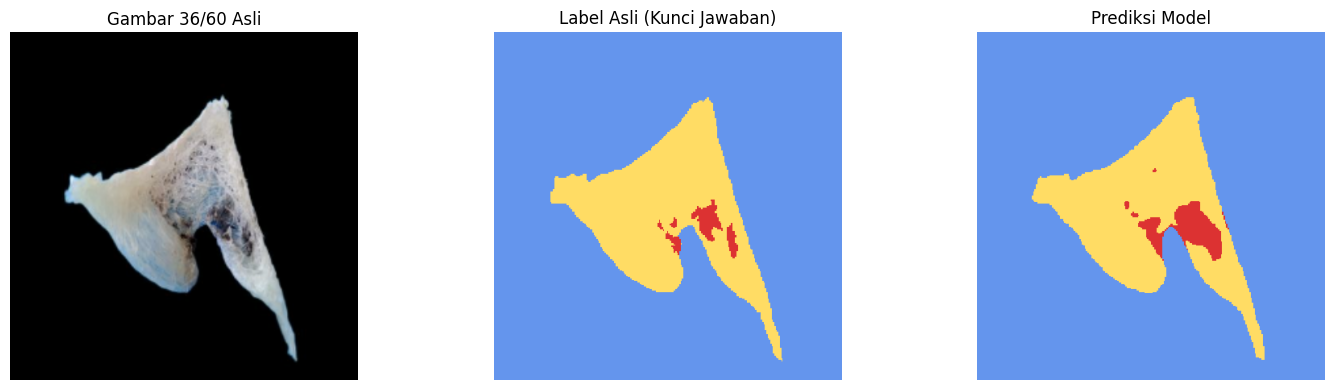

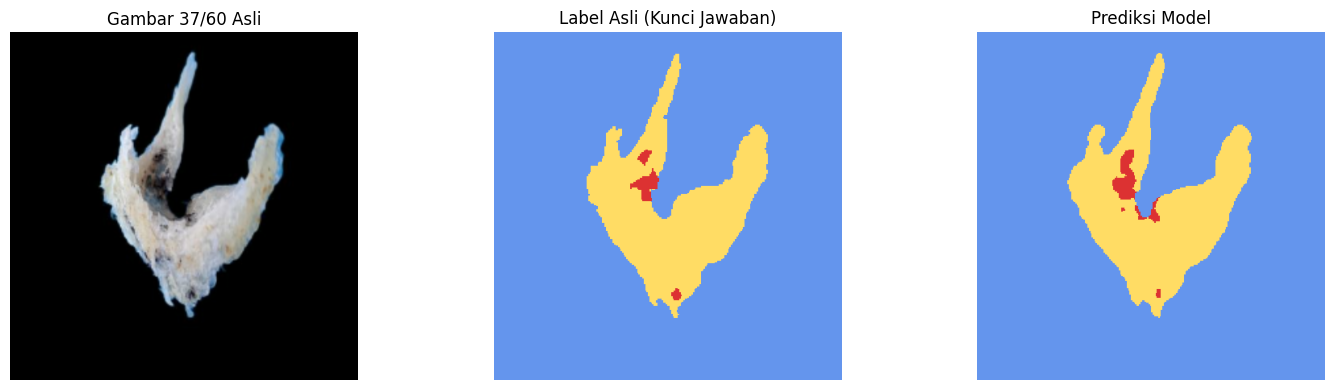

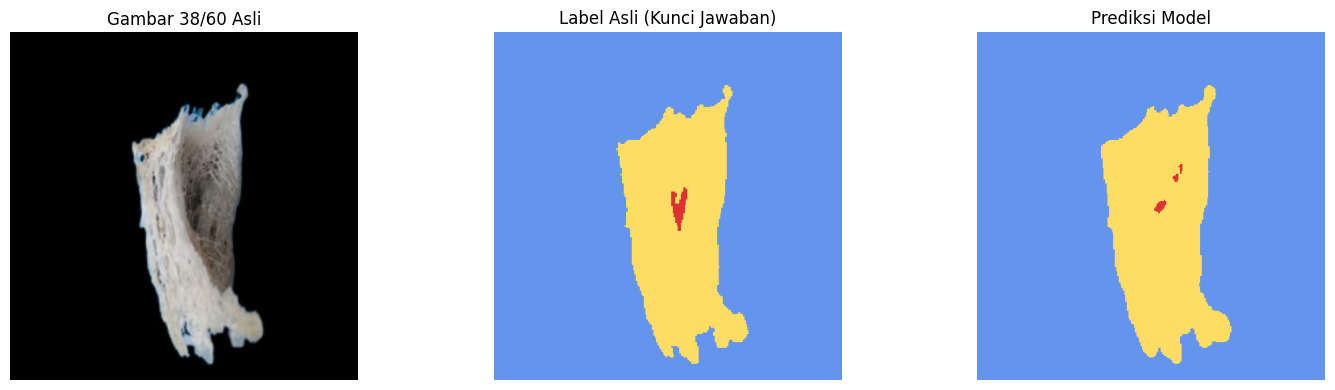

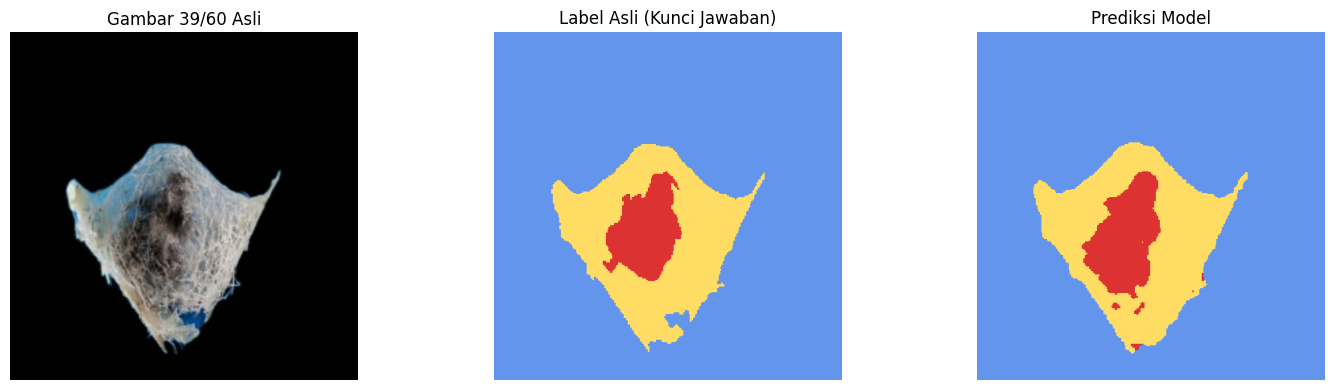

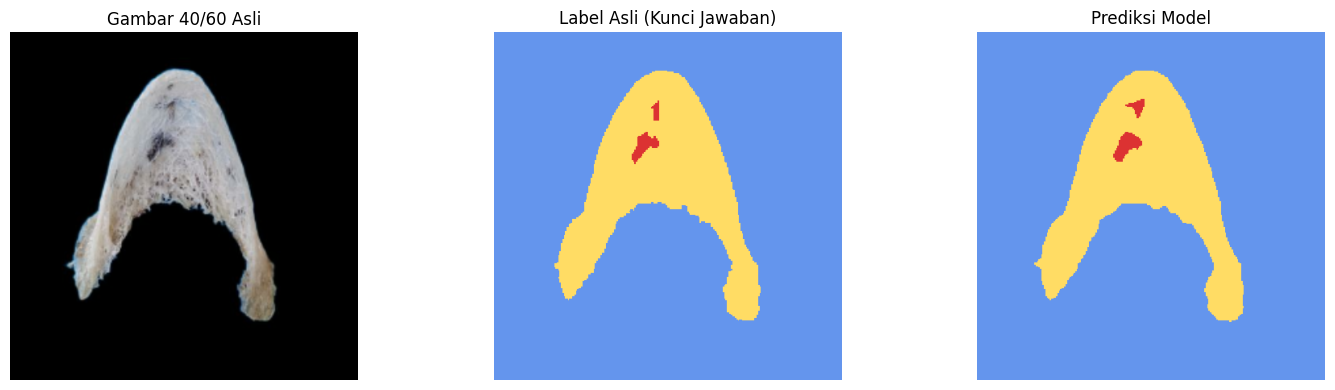

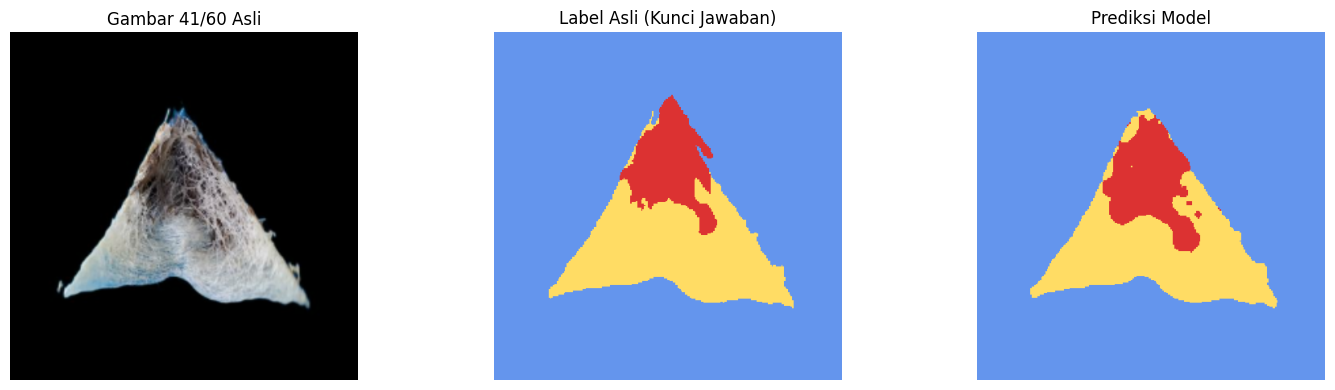

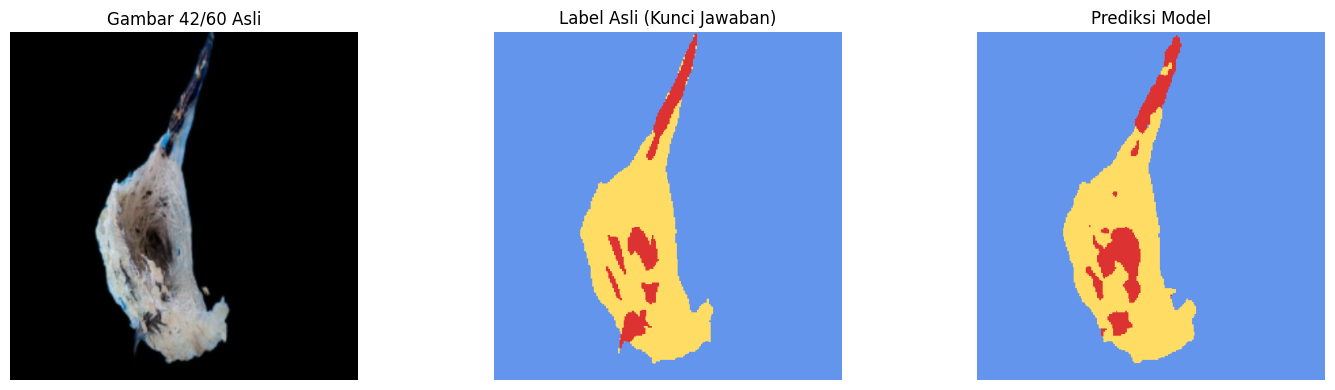

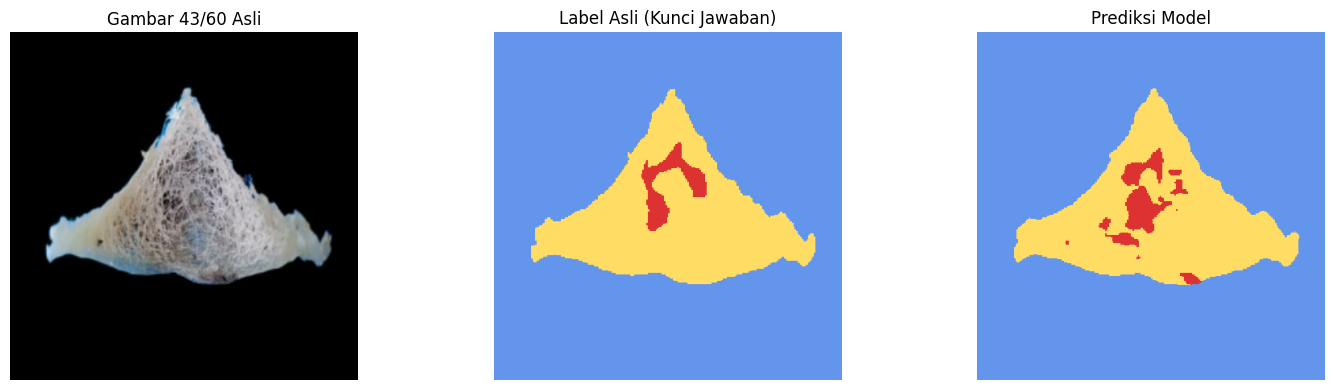

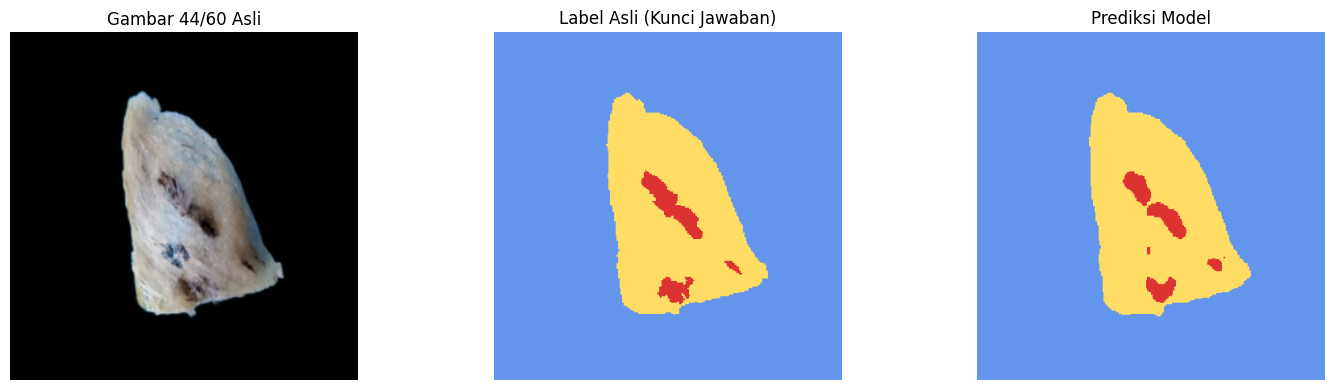

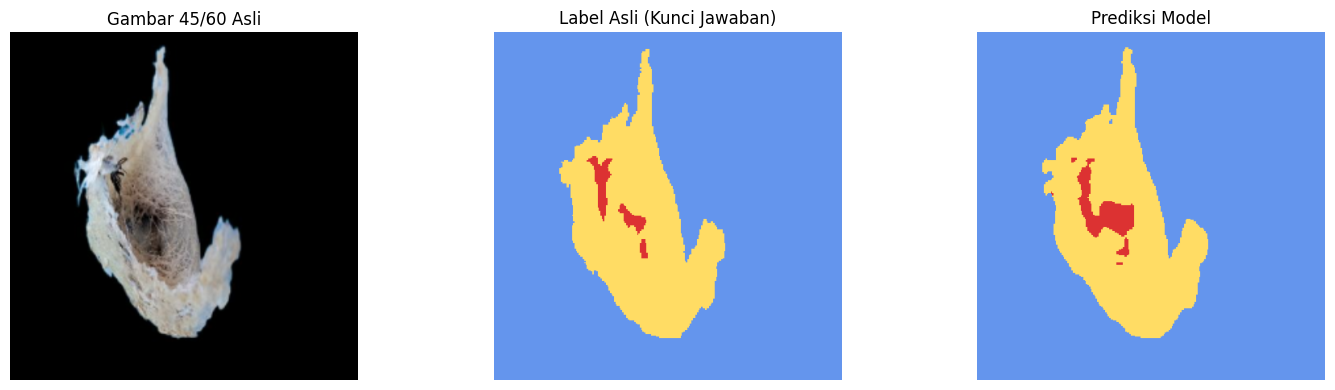

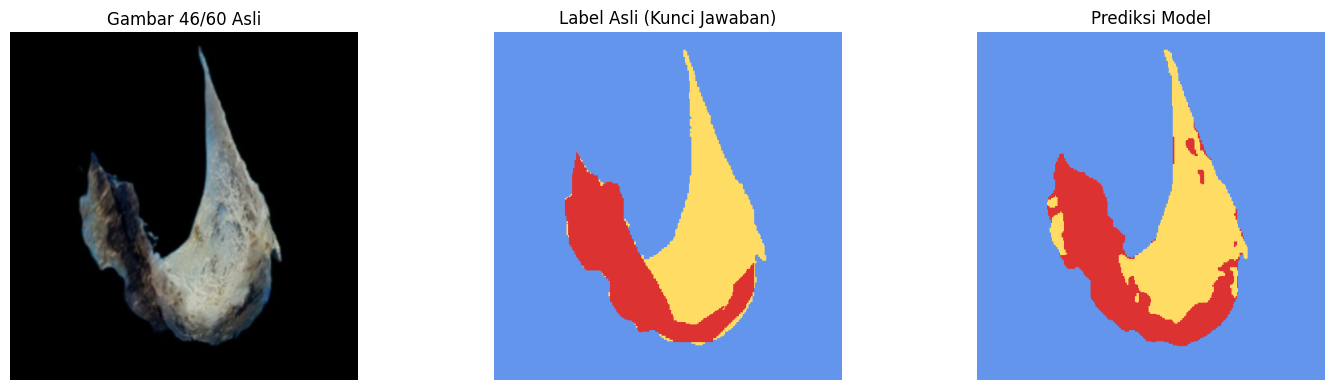

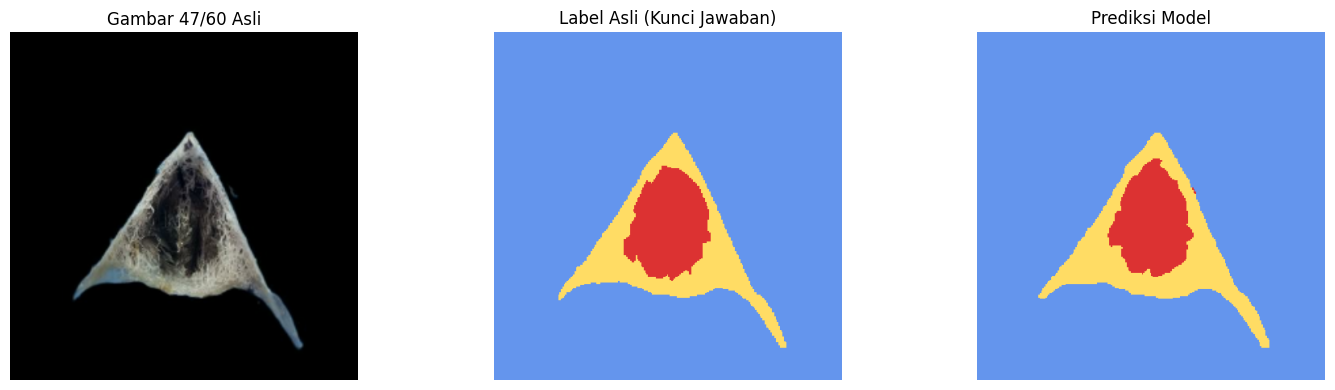

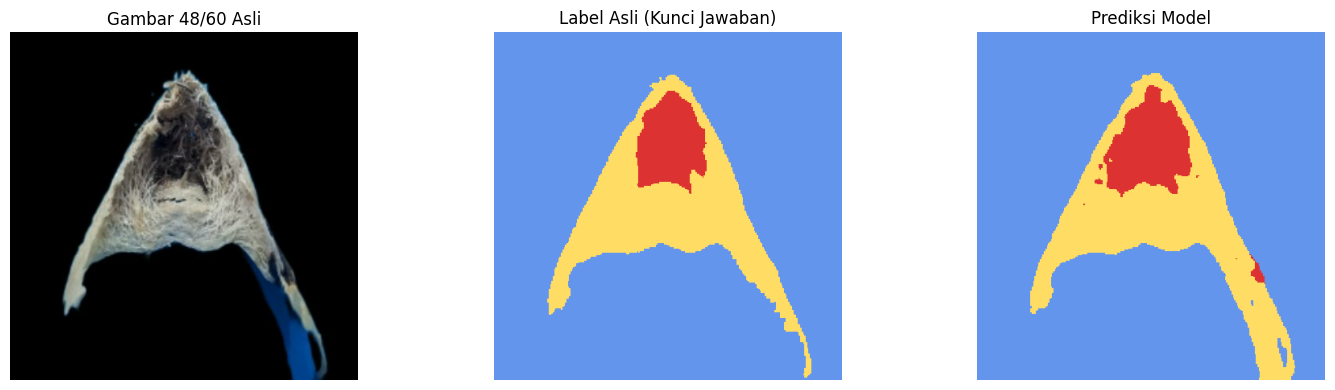

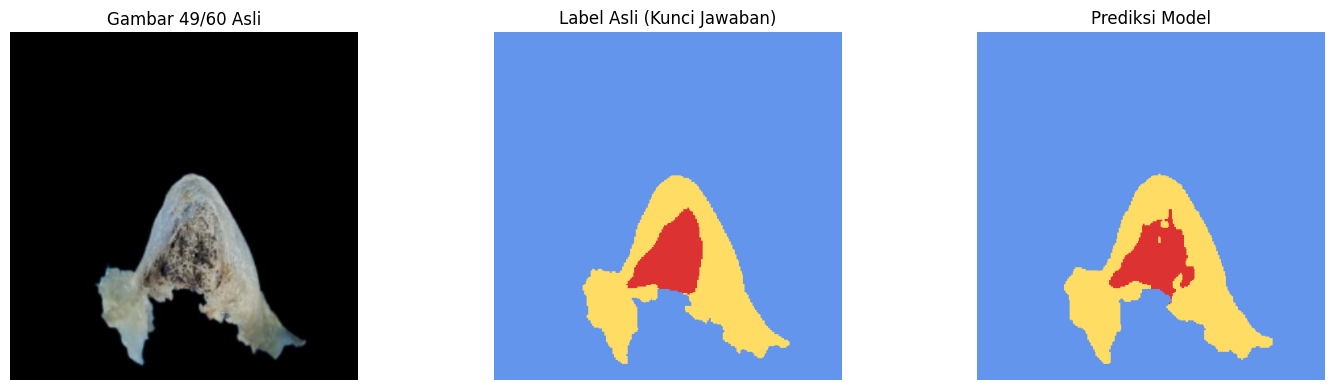

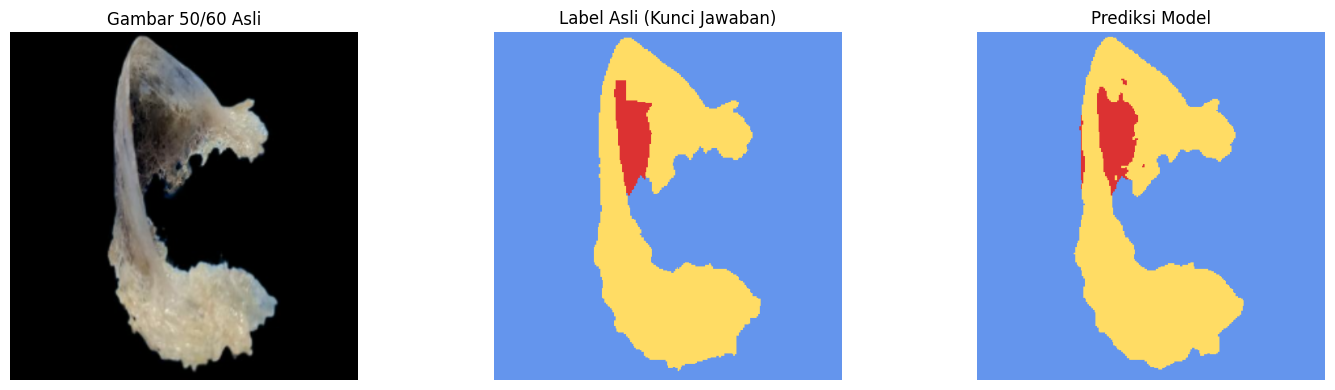

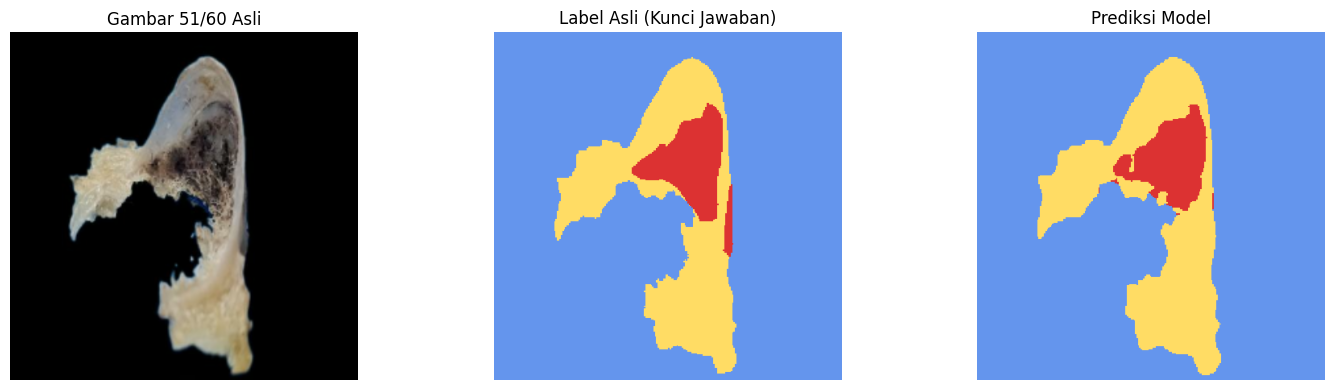

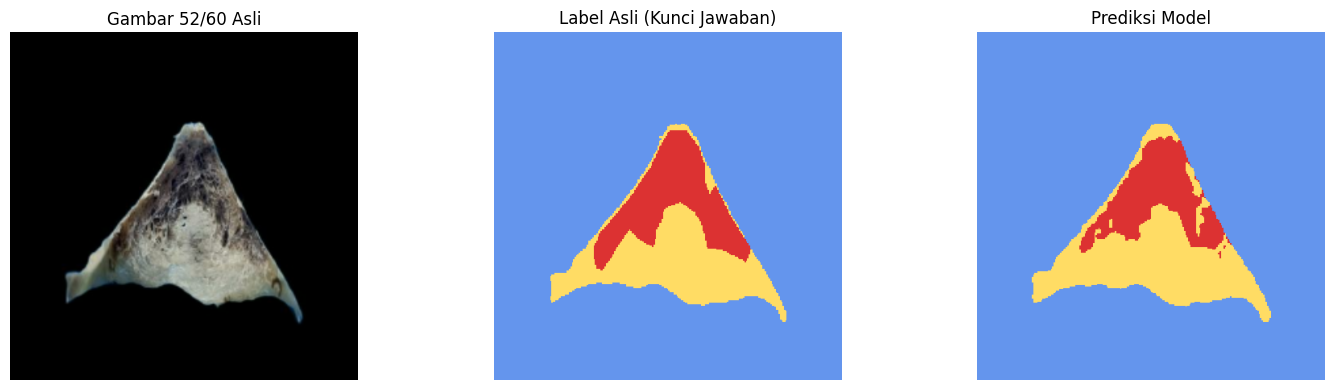

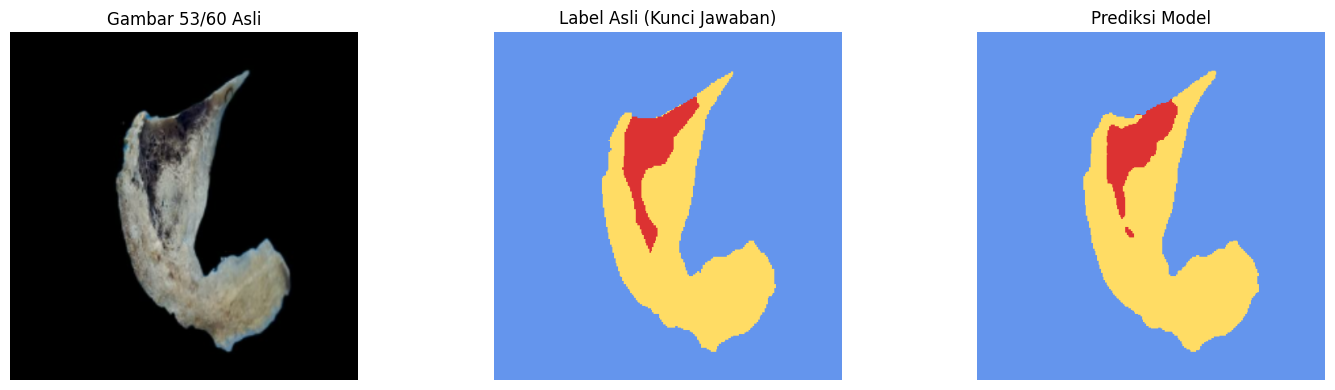

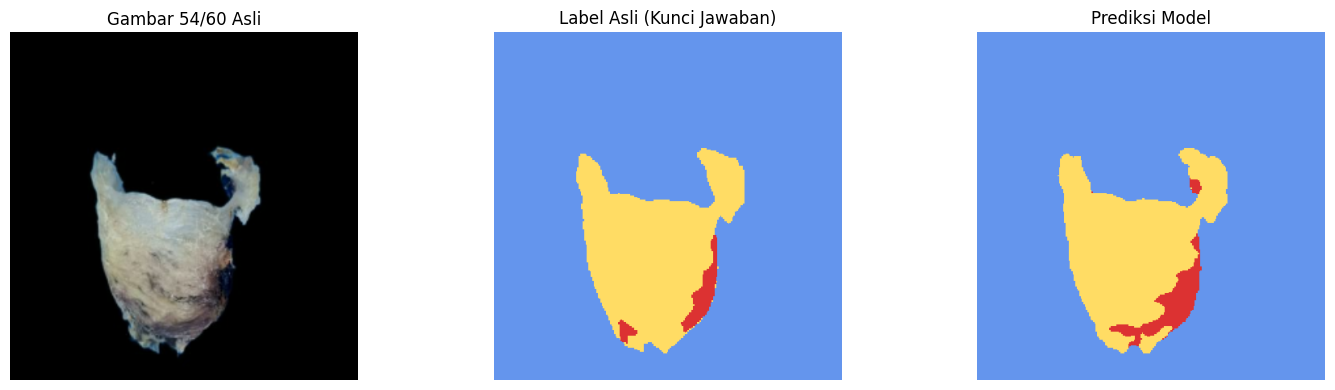

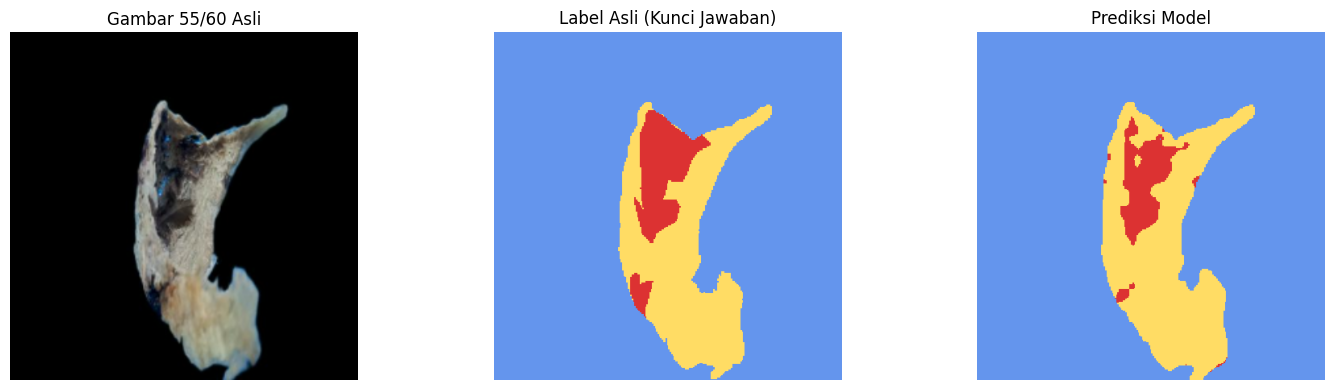

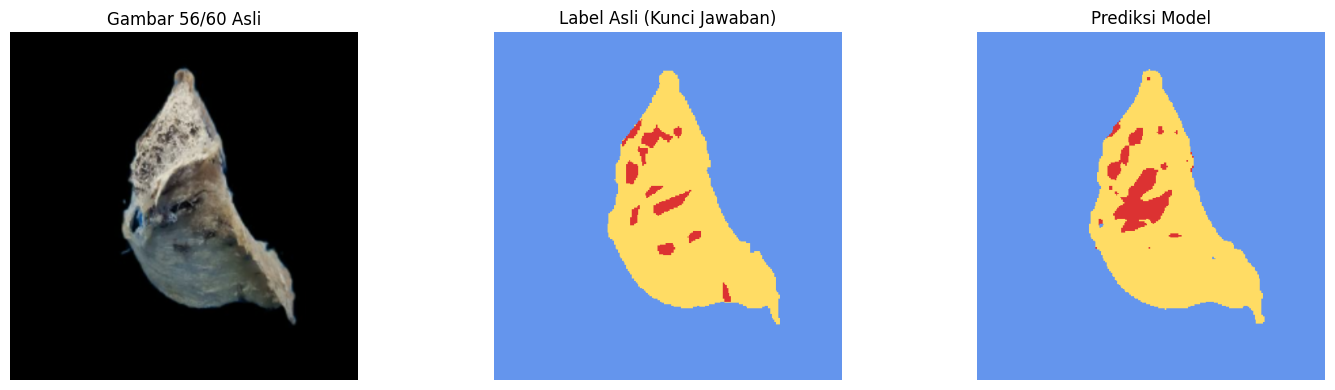

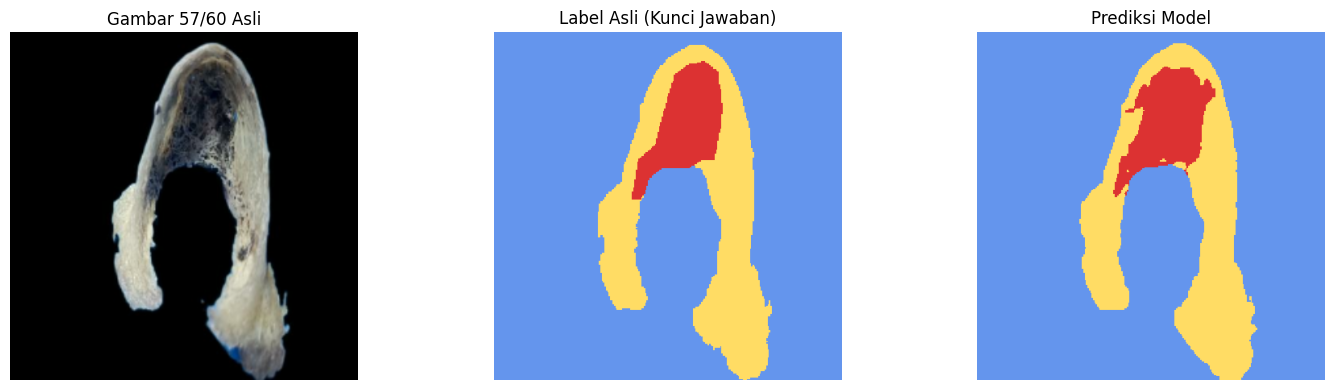

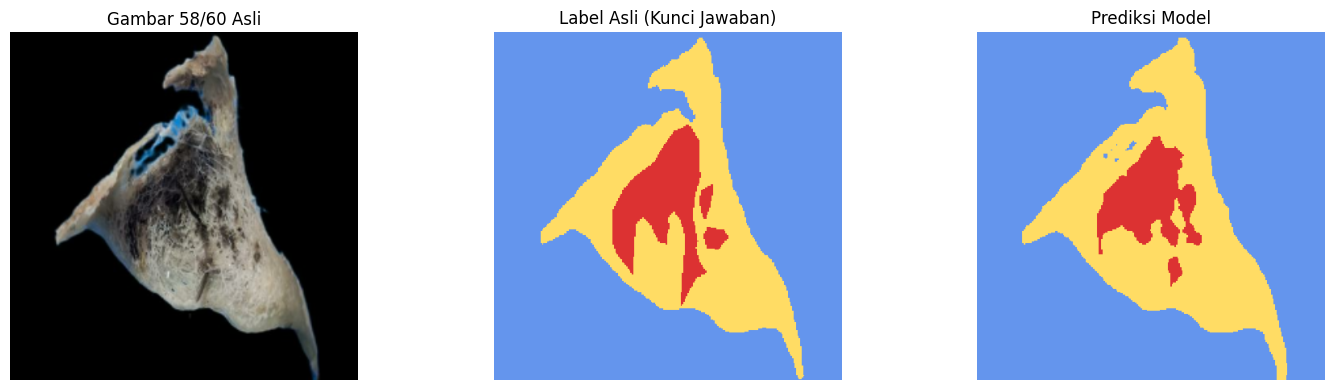

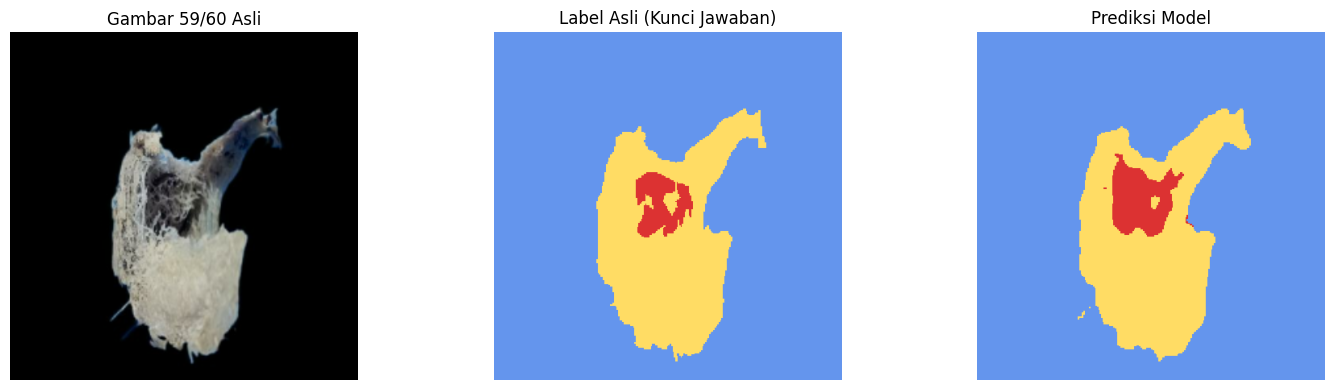

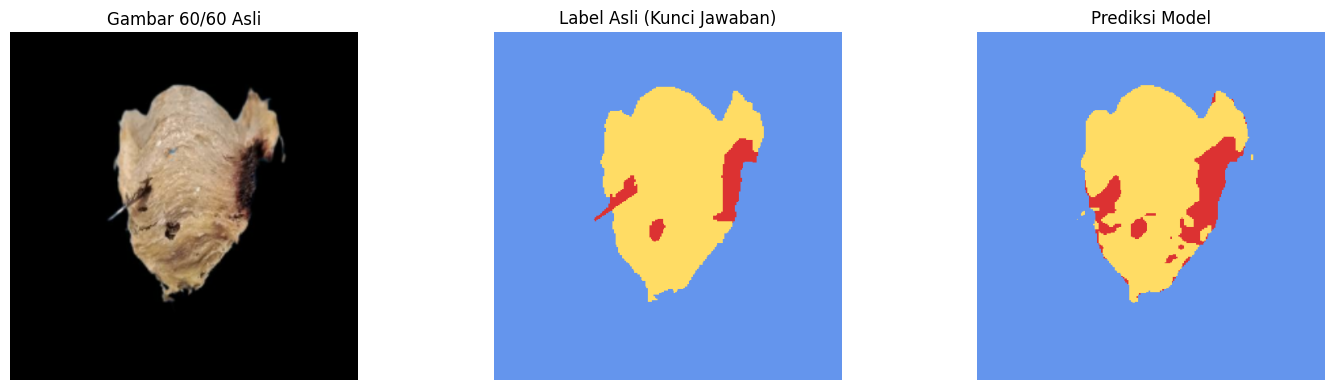

Selesai menampilkan 60 gambar validasi.


In [33]:
# Menampilkan SEMUA hasil prediksi pada Validation Set untuk koreksi
print("Menampilkan seluruh hasil prediksi gambar validasi...")
print("Gunakan hasil ini untuk membandingkan Label Asli vs Prediksi Model.")

import numpy as np
import cv2

valid_ds_unbatched = valid_dataset.unbatch()
num_images = len(valid_images)

for i, (img, mask) in enumerate(valid_ds_unbatched):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Dapatkan resolusi gambar aslinya dari file path asli
    orig_path = valid_images[i]
    orig_img_cv = cv2.imread(orig_path)
    if orig_img_cv is not None:
        orig_h, orig_w = orig_img_cv.shape[:2]
    else:
        # Fallback jika gagal baca gambar
        orig_h, orig_w = 256, 256

    # Lakukan prediksi di resolusi 256x256
    pred = model(tf.expand_dims(img, 0), training=False)[0]
    pred_mask = tf.argmax(pred, axis=-1)
    pred_mask = tf.cast(pred_mask, tf.uint8)

    # Normalisasi gambar untuk ditampilkan
    img_disp = (img.numpy() * 255).astype(np.uint8)

    # Ubah mask 2D ke RGB
    true_rgb = mask_to_rgb(np.squeeze(mask.numpy()))
    pred_rgb = mask_to_rgb(np.squeeze(pred_mask.numpy()))

    # KEMBALIKAN KE RESOLUSI ASLI AGAR TIDAK TERLIHAT DICIUTKAN
    img_disp_orig = cv2.resize(img_disp, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    true_rgb_orig = cv2.resize(true_rgb, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    pred_rgb_orig = cv2.resize(pred_rgb, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # Gambar Asli
    axes[0].imshow(img_disp_orig)
    axes[0].set_title(f"Gambar {i+1}/{num_images} Asli")
    axes[0].axis('off')

    # True Mask (Kunci Jawaban)
    axes[1].imshow(true_rgb_orig)
    axes[1].set_title(f"Label Asli (Kunci Jawaban)")
    axes[1].axis('off')

    # Predicted Mask
    axes[2].imshow(pred_rgb_orig)
    axes[2].set_title(f"Prediksi Model")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print(f"Selesai menampilkan {num_images} gambar validasi.")

### Menambahkan Confidence Threshold pada Prediksi
Kode di bawah ini akan mengabaikan prediksi jika tingkat keyakinan model di bawah `CONFIDENCE_THRESHOLD`. Piksel yang tidak memenuhi threshold akan dikategorikan sebagai Background (Kelas 0).

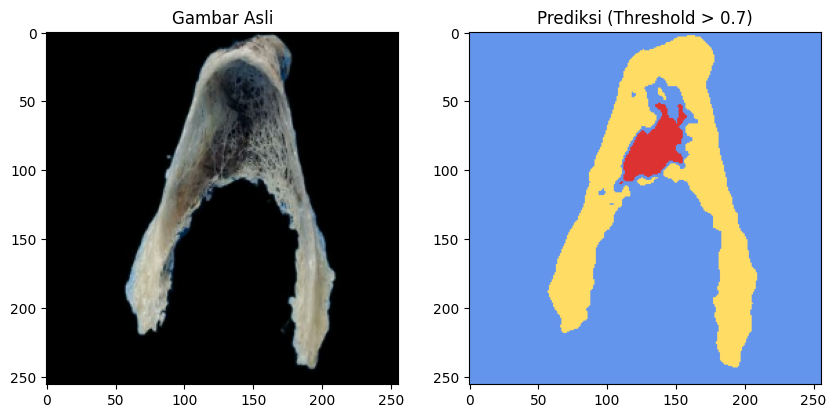

In [34]:
def predict_with_threshold(model, image, threshold=0.5):
    # 1. Dapatkan probabilitas (softmax output)
    preds = model(tf.expand_dims(image, 0), training=False)[0]
    preds = preds.numpy().astype(np.float32)

    # 2. Cari probabilitas tertinggi untuk setiap piksel
    max_probs = np.max(preds, axis=-1)

    # 3. Cari kelas dengan probabilitas tertinggi
    predicted_classes = np.argmax(preds, axis=-1)

    # 4. Terapkan threshold:
    # Jika max_prob < threshold, ubah kelas menjadi 0 (Background)
    final_mask = np.where(max_probs >= threshold, predicted_classes, 0)

    return final_mask.astype(np.uint8)

# Contoh penggunaan:
THRESHOLD_VALUE = 0.7 # Model harus 70% yakin
sample_img, _ = next(iter(valid_dataset.unbatch().take(1)))
mask_thresh = predict_with_threshold(model, sample_img, threshold=THRESHOLD_VALUE)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Gambar Asli")
plt.imshow(sample_img)
plt.subplot(1, 2, 2)
plt.title(f"Prediksi (Threshold > {THRESHOLD_VALUE})")
plt.imshow(mask_to_rgb(mask_thresh))
plt.show()

In [35]:
# Menyimpan model versi Light ke Google Drive (tanpa download ke komputer)
import shutil
import keras_cv
import os

try:
    # 1. Simpan model asli sementara untuk menampilkan ukurannya
    print("Menghitung ukuran model asli...")
    LOCAL_ORIGINAL_PATH = "/content/deeplabv3plus_walet_original.keras"
    model.save(LOCAL_ORIGINAL_PATH)
    original_size = os.path.getsize(LOCAL_ORIGINAL_PATH) / 1024 / 1024

    # 2. Buat model ringan (tanpa optimizer)
    print("Membuat model versi ringan (tanpa optimizer)...")
    backbone_new = keras_cv.models.ResNet50V2Backbone.from_preset(
        preset=train_cfg.BACKBONE,
        input_shape=data_cfg.IMAGE_SIZE + (3,),
        load_weights=False,
    )
    model_light = keras_cv.models.segmentation.DeepLabV3Plus(
        num_classes=data_cfg.NUM_CLASSES,
        backbone=backbone_new,
    )
    model_light.build((None,) + data_cfg.IMAGE_SIZE + (3,))
    model_light.set_weights(model.get_weights())

    # 3. Simpan model ringan
    LOCAL_LIGHT_PATH = "/content/deeplabv3plus_walet_light.keras"
    model_light.save(LOCAL_LIGHT_PATH)
    light_size = os.path.getsize(LOCAL_LIGHT_PATH) / 1024 / 1024

    print("=" * 55)
    print(f"  Ukuran Model Asli (dengan optimizer) : {original_size:.1f} MB")
    print(f"  Ukuran Model Ringan (tanpa optimizer) : {light_size:.1f} MB")
    print(f"  Hemat : {(1 - light_size/original_size)*100:.1f}%")
    print("=" * 55)

    # 4. Salin model ringan ke Google Drive
    DRIVE_LIGHT_PATH = f"{OUTPUT_DIR}/deeplabv3plus_walet_light.keras"
    shutil.copy2(LOCAL_LIGHT_PATH, DRIVE_LIGHT_PATH)
    print(f"Model ringan berhasil disimpan ke Google Drive:")
    print(f"  -> {DRIVE_LIGHT_PATH}")

    # 5. Hapus file sementara di Colab untuk menghemat storage
    if os.path.exists(LOCAL_ORIGINAL_PATH):
        os.remove(LOCAL_ORIGINAL_PATH)
    if os.path.exists(LOCAL_LIGHT_PATH):
        os.remove(LOCAL_LIGHT_PATH)

    print("File sementara di Colab sudah dibersihkan.")
    print("Semua hasil (grafik, log, model) tersimpan di Google Drive!")

except Exception as e:
    print(f"ERROR: {e}")


Menghitung ukuran model asli...
Membuat model versi ringan (tanpa optimizer)...
  Ukuran Model Asli (dengan optimizer) : 747.6 MB
  Ukuran Model Ringan (tanpa optimizer) : 150.0 MB
  Hemat : 79.9%
Model ringan berhasil disimpan ke Google Drive:
  -> /content/drive/MyDrive/Skripsi (1)/Hasil_B8_E100_LR0.0001/deeplabv3plus_walet_light.keras
File sementara di Colab sudah dibersihkan.
Semua hasil (grafik, log, model) tersimpan di Google Drive!


In [36]:
# menampilkan dan menyimpan ringkasan hasil akhir pelatihan dan evaluasi
summary_text = []
summary_text.append("=" * 65)
summary_text.append("          RINGKASAN HASIL AKHIR PELATIHAN & EVALUASI")
summary_text.append("=" * 65)
summary_text.append(f"  Backbone          : {train_cfg.BACKBONE}")
summary_text.append(f"  Image Size        : {data_cfg.IMAGE_SIZE}")
summary_text.append(f"  Batch Size        : {data_cfg.BATCH_SIZE}")
summary_text.append(f"  Mixed Precision   : float16")
summary_text.append(f"  Num Classes       : {data_cfg.NUM_CLASSES}")
summary_text.append(f"  Epochs Dijalankan : {len(history.history['loss'])}")
summary_text.append(f"  Learning Rate     : {train_cfg.LEARNING_RATE}")
summary_text.append(f"  Class Weights     : {dict(enumerate(CLASS_WEIGHTS_LIST))}")
summary_text.append("")
summary_text.append("  --- Validation Set ---")
summary_text.append(f"  Pixel Accuracy : {val_results['pixel_accuracy']:.4f} ({val_results['pixel_accuracy']*100:.2f}%)")
summary_text.append(f"  Mean IoU       : {val_results['mean_iou']:.4f} ({val_results['mean_iou']*100:.2f}%)")
summary_text.append(f"  Mean Precision : {val_results['mean_precision']:.4f}")
summary_text.append(f"  Mean Recall    : {val_results['mean_recall']:.4f}")
summary_text.append(f"  Mean F1-Score  : {val_results['mean_f1']:.4f}")
summary_text.append("")
label = 'Test Set' if HAS_TEST else 'Test Set (= Validation)'
summary_text.append(f"  --- {label} ---")
summary_text.append(f"  Pixel Accuracy : {test_results['pixel_accuracy']:.4f} ({test_results['pixel_accuracy']*100:.2f}%)")
summary_text.append(f"  Mean IoU       : {test_results['mean_iou']:.4f} ({test_results['mean_iou']*100:.2f}%)")
summary_text.append(f"  Mean Precision : {test_results['mean_precision']:.4f}")
summary_text.append(f"  Mean Recall    : {test_results['mean_recall']:.4f}")
summary_text.append(f"  Mean F1-Score  : {test_results['mean_f1']:.4f}")
summary_text.append("")
summary_text.append(f"  {'Kelas':<20} {'IoU':>8} {'Precision':>10} {'Recall':>8} {'F1-Score':>10}")
summary_text.append(f"  {'-'*60}")
for i, name in enumerate(CLASS_NAMES):
    summary_text.append(f"  {name:<20} "
          f"{test_results['iou_per_class'][i]:>8.4f} "
          f"{test_results['precision_per_class'][i]:>10.4f} "
          f"{test_results['recall_per_class'][i]:>8.4f} "
          f"{test_results['f1_per_class'][i]:>10.4f}")
summary_text.append("=" * 65)

# Gabungkan menjadi satu string
final_summary = "\n".join(summary_text)

# Tampilkan di layar
print(final_summary)

# Simpan ke file teks di dalam OUTPUT_DIR
summary_path = f"{OUTPUT_DIR}/ringkasan_evaluasi.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(final_summary)

print(f"\n✅ Ringkasan berhasil disimpan ke: {summary_path}")


          RINGKASAN HASIL AKHIR PELATIHAN & EVALUASI
  Backbone          : resnet50_v2_imagenet
  Image Size        : (256, 256)
  Batch Size        : 8
  Mixed Precision   : float16
  Num Classes       : 3
  Epochs Dijalankan : 76
  Learning Rate     : 0.0001
  Class Weights     : {0: 1.0, 1: 9.0, 2: 5.0}

  --- Validation Set ---
  Pixel Accuracy : 0.9844 (98.44%)
  Mean IoU       : 0.8501 (85.01%)
  Mean Precision : 0.9078
  Mean Recall    : 0.9148
  Mean F1-Score  : 0.9113

  --- Test Set (= Validation) ---
  Pixel Accuracy : 0.9844 (98.44%)
  Mean IoU       : 0.8501 (85.01%)
  Mean Precision : 0.9078
  Mean Recall    : 0.9148
  Mean F1-Score  : 0.9113

  Kelas                     IoU  Precision   Recall   F1-Score
  ------------------------------------------------------------
  Background             0.9917     0.9989   0.9928     0.9958
  Kotoran                0.6394     0.7796   0.7806     0.7801
  Sarang Bersih          0.9193     0.9451   0.9711     0.9579

✅ Ringkasan berhas